In [1]:
from sqlalchemy.orm import sessionmaker
from PanoDB_link import engine,CommandLog
import pandas as pd
from datetime import datetime, timezone
import pytz
import json
import numpy as np

paris = pytz.timezone("Europe/Paris")

mois={
    1 :"janvier",
    2 :"février",
    3 :"mars",
    4 :"avril",
    5 :"mai",
    6 :"juin",
    7 :"juillet",
    8 :"août",
    9 :"septembre",
    10 :"octobre",
    11 :"novembre",
    12 :"décembre",   
}

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from matplotlib import font_manager as fm
import os

# Exemple avec Segoe UI Emoji (Windows)
emoji_font_path = "C:/Windows/Fonts/seguiemj.ttf"

# Vérifier que le fichier existe
if os.path.exists(emoji_font_path):
    emoji_font = fm.FontProperties(fname=emoji_font_path)
    print("Emoji font loaded successfully!")
else:
    emoji_font = None
    print("Emoji font not found, using default font")

# Utilisation dans Matplotlib
# plt.rcParams['font.family'] = emoji_font.get_name() if emoji_font else 'DejaVu Sans'


Emoji font loaded successfully!


In [2]:
# Avec SQLAlchemy engine
logs = pd.read_sql("SELECT * FROM command_logs", con=engine)
logs['executed_at'] = logs['executed_at'].dt.tz_localize('UTC').dt.tz_convert('Europe/Paris')
logs.tail()


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
4801,4802,2025-10-21 03:40:43+02:00,1.334696e+18,dondovy,1.428809e+18,ATLASIUM,1.429721e+18,commands-bot,stuff,"{""element"": ""dopou""}"
4802,4803,2025-10-21 03:48:12+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,stuff,"{""classe"": ""ecaflip""}"
4803,4804,2025-10-21 03:49:04+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,bibliotheques,{}
4804,4805,2025-10-21 03:49:45+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,stuff,"{""classe"": ""ecaflip"", ""lvl_max"": 90}"
4805,4806,2025-10-21 04:05:49+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.429404e+18,db-gamosaurus,stuff,{}


In [3]:
logs_users=logs[logs["user_name"]!="warp_is_fine"]
logs_users

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
126,127,2025-02-06 09:51:00+01:00,8.476086e+17,blusterdofus,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""air""}"
127,128,2025-02-06 18:49:51+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau""}"
128,129,2025-02-06 18:50:24+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau docrit""}"
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
...,...,...,...,...,...,...,...,...,...,...
4754,4755,2025-10-21 00:58:07+02:00,4.084036e+17,levelesbras,1.301967e+18,Horizon,1.396101e+18,🥋┃banque-de-stuff,stuff,"{""classe"": ""sram"", ""pa_min"": 12, ""element"": ""a..."
4758,4759,2025-10-21 01:11:33+02:00,5.884525e+17,heartgamer.,1.224770e+18,Stellar - Dofus TOUCH,1.229493e+18,🏹stuffs,stuff,"{""element"": ""feu aur""}"
4759,4760,2025-10-21 01:11:44+02:00,5.884525e+17,heartgamer.,1.224770e+18,Stellar - Dofus TOUCH,1.229493e+18,🏹stuffs,stuff,"{""element"": ""feu eau""}"
4800,4801,2025-10-21 03:26:57+02:00,1.300497e+18,stayhardbroxd_64980,1.224770e+18,Stellar - Dofus TOUCH,1.229493e+18,🏹stuffs,dofusbook,{}


In [4]:
logs_warp=logs[logs["user_name"]=="warp_is_fine"]
logs_warp

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
0,1,2025-09-22 23:53:41+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
1,2,2025-09-22 23:55:28+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test""}"
2,3,2025-09-22 23:58:00+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test2""}"
3,4,2025-02-01 23:13:43+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
4,5,2025-02-01 23:15:11+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
...,...,...,...,...,...,...,...,...,...,...
4799,4800,2025-10-21 03:13:51+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,stuff,"{""classe"": ""ecaflip""}"
4802,4803,2025-10-21 03:48:12+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,stuff,"{""classe"": ""ecaflip""}"
4803,4804,2025-10-21 03:49:04+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,bibliotheques,{}
4804,4805,2025-10-21 03:49:45+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,stuff,"{""classe"": ""ecaflip"", ""lvl_max"": 90}"


In [5]:
nb_logs=len(logs)
nb_logs_users=len(logs_users)
nb_logs_guild_id_null=len(logs[logs["guild_id"].isna()])
nb_logs_guild_id_null_unique=len(logs[logs["guild_id"].isna()]["guild_name"].unique())
nb_guild_names=len(logs["guild_name"].unique())
nb_logs_channel_id_null=len(logs[logs["channel_id"].isna()])
nb_logs_channel_id_null_unique=len(logs[logs["channel_id"].isna()]["channel_name"].unique())
nb_channel_names=len(logs["channel_name"].unique())
nb_logs_user_id_null=len(logs[logs["user_id"].isna()])
nb_logs_user_id_null_unique=len(logs[logs["user_id"].isna()]["user_name"].unique())
nb_user_names=len(logs["user_name"].unique())

print(f"Nombre de logs : {nb_logs}")
print(f"Nombre de logs sans warp : {nb_logs_users}")
print(f"Nombre de guilds : {nb_guild_names}")
print(f"Nombre de channels : {nb_channel_names}")
print(f"Nombre de users : {nb_user_names}")
print(f"Nombre de logs avec guild_id NULL : {nb_logs_guild_id_null} pour {nb_logs_guild_id_null_unique} uniques guild_name")
print(f"Nombre de logs avec channel_id NULL : {nb_logs_channel_id_null} pour {nb_logs_channel_id_null_unique} uniques channel_name")
print(f"Nombre de logs avec user_id NULL : {nb_logs_user_id_null} pour {nb_logs_user_id_null_unique} uniques user_name")


Nombre de logs : 4806
Nombre de logs sans warp : 3370
Nombre de guilds : 98
Nombre de channels : 167
Nombre de users : 534
Nombre de logs avec guild_id NULL : 193 pour 17 uniques guild_name
Nombre de logs avec channel_id NULL : 359 pour 39 uniques channel_name
Nombre de logs avec user_id NULL : 315 pour 104 uniques user_name


# commandes à un temps précis

In [6]:
logs[logs["executed_at"] > paris.localize(datetime(2025, 2, 5, 0, 0, 1))][logs["executed_at"] > paris.localize(datetime(2025, 1, 23, 0, 0, 1))].sort_values(by="executed_at")

C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\364389784.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  logs[logs["executed_at"] > paris.localize(datetime(2025, 2, 5, 0, 0, 1))][logs["executed_at"] > paris.localize(datetime(2025, 1, 23, 0, 0, 1))].sort_values(by="executed_at")


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
125,126,2025-02-05 18:20:31+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""patate""}"
126,127,2025-02-06 09:51:00+01:00,8.476086e+17,blusterdofus,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""air""}"
127,128,2025-02-06 18:49:51+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau""}"
128,129,2025-02-06 18:50:24+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau docrit""}"
129,130,2025-02-06 23:25:26+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""feu""}"
...,...,...,...,...,...,...,...,...,...,...
4801,4802,2025-10-21 03:40:43+02:00,1.334696e+18,dondovy,1.428809e+18,ATLASIUM,1.429721e+18,commands-bot,stuff,"{""element"": ""dopou""}"
4802,4803,2025-10-21 03:48:12+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,stuff,"{""classe"": ""ecaflip""}"
4803,4804,2025-10-21 03:49:04+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,bibliotheques,{}
4804,4805,2025-10-21 03:49:45+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.425601e+18,db-retro,stuff,"{""classe"": ""ecaflip"", ""lvl_max"": 90}"


# commandes d'un serveur précis

In [7]:
logs_users.loc[logs_users["guild_id"]==933448236939743360.0]
# logs_users.loc[logs_users["guild_name"]=="La Secte"]

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
134,135,2025-02-09 10:21:48+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""xelor""}"
139,140,2025-02-13 17:58:41+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""feu""}"
140,141,2025-02-13 17:59:05+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air""}"
...,...,...,...,...,...,...,...,...,...,...
4735,4736,2025-10-21 00:04:01+02:00,4.933918e+17,nokz76,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""terre eau""}"
4736,4737,2025-10-21 00:04:18+02:00,4.933918e+17,nokz76,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""steamer""}"
4737,4738,2025-10-21 00:04:47+02:00,4.933918e+17,nokz76,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""steamer""}"
4738,4739,2025-10-21 00:06:10+02:00,9.434561e+17,baz10k,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""ecaflip""}"


# commandes d'un utilisateur précis

In [8]:
user="horaj_"
logs.loc[logs["user_name"]==user]

# userid=357960636509978624
# logs.loc[logs["user_id"]==userid]


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
2604,2605,2025-08-01 01:36:55+02:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
3464,3465,2025-09-09 14:54:06+02:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}


# utilisation des commandes

## utilisation des commandes utilisateurs

C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\1125364631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\1125364631.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_users['week'] = logs_users['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\1125364631.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

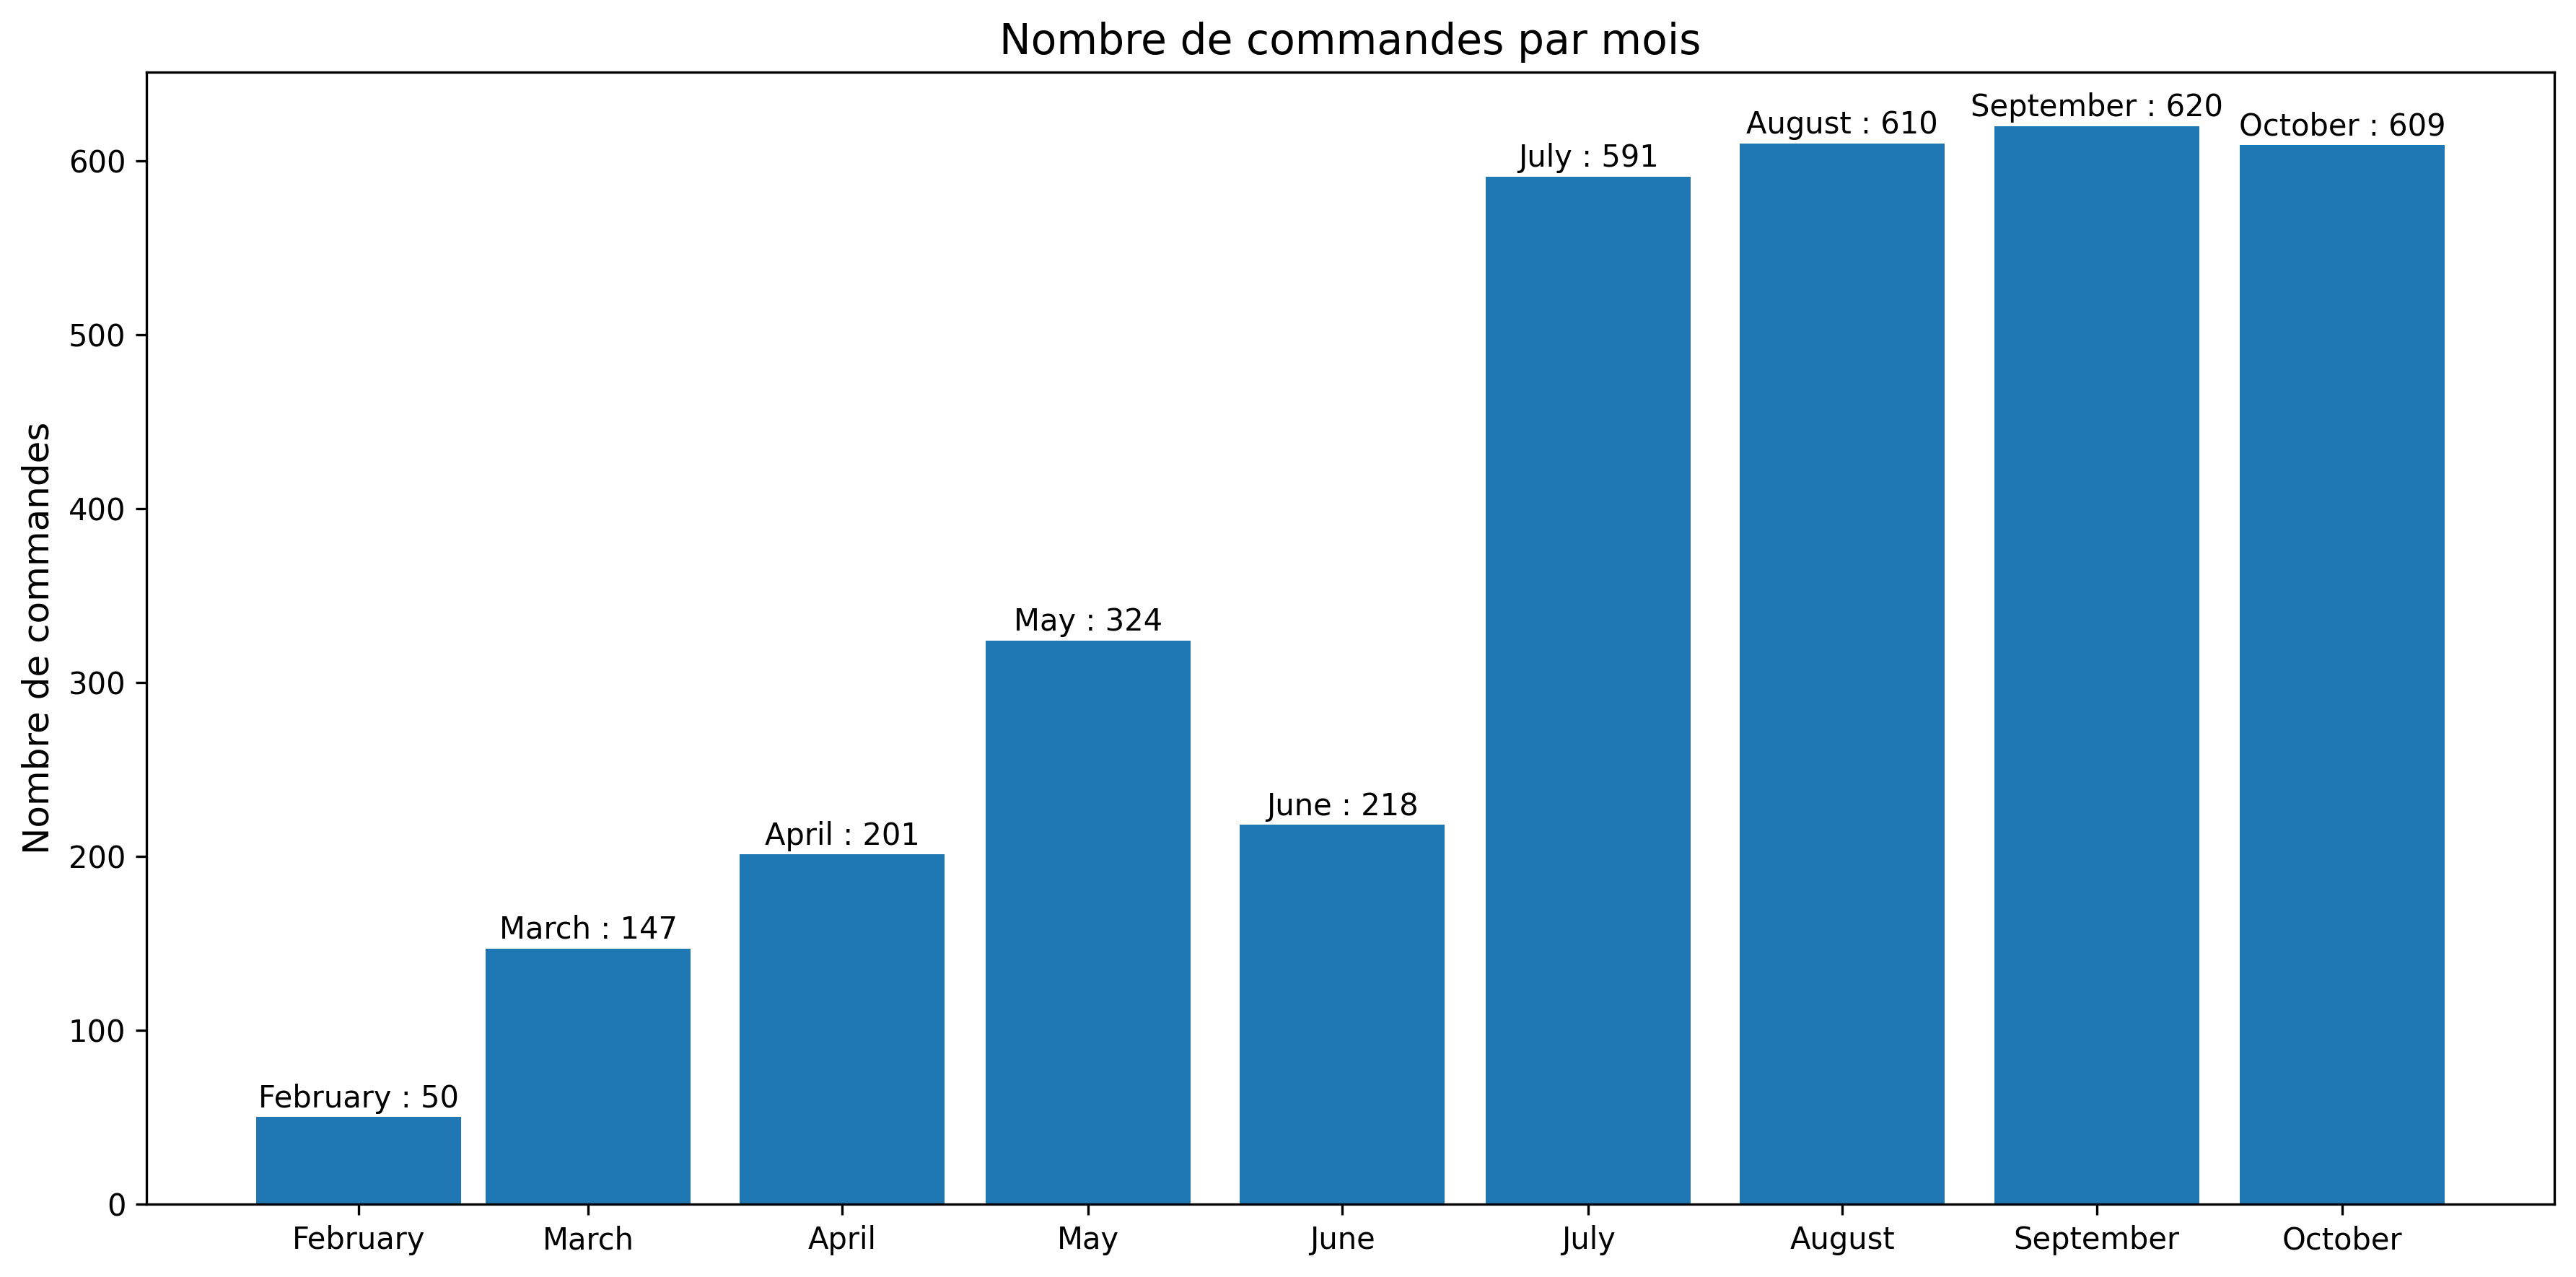

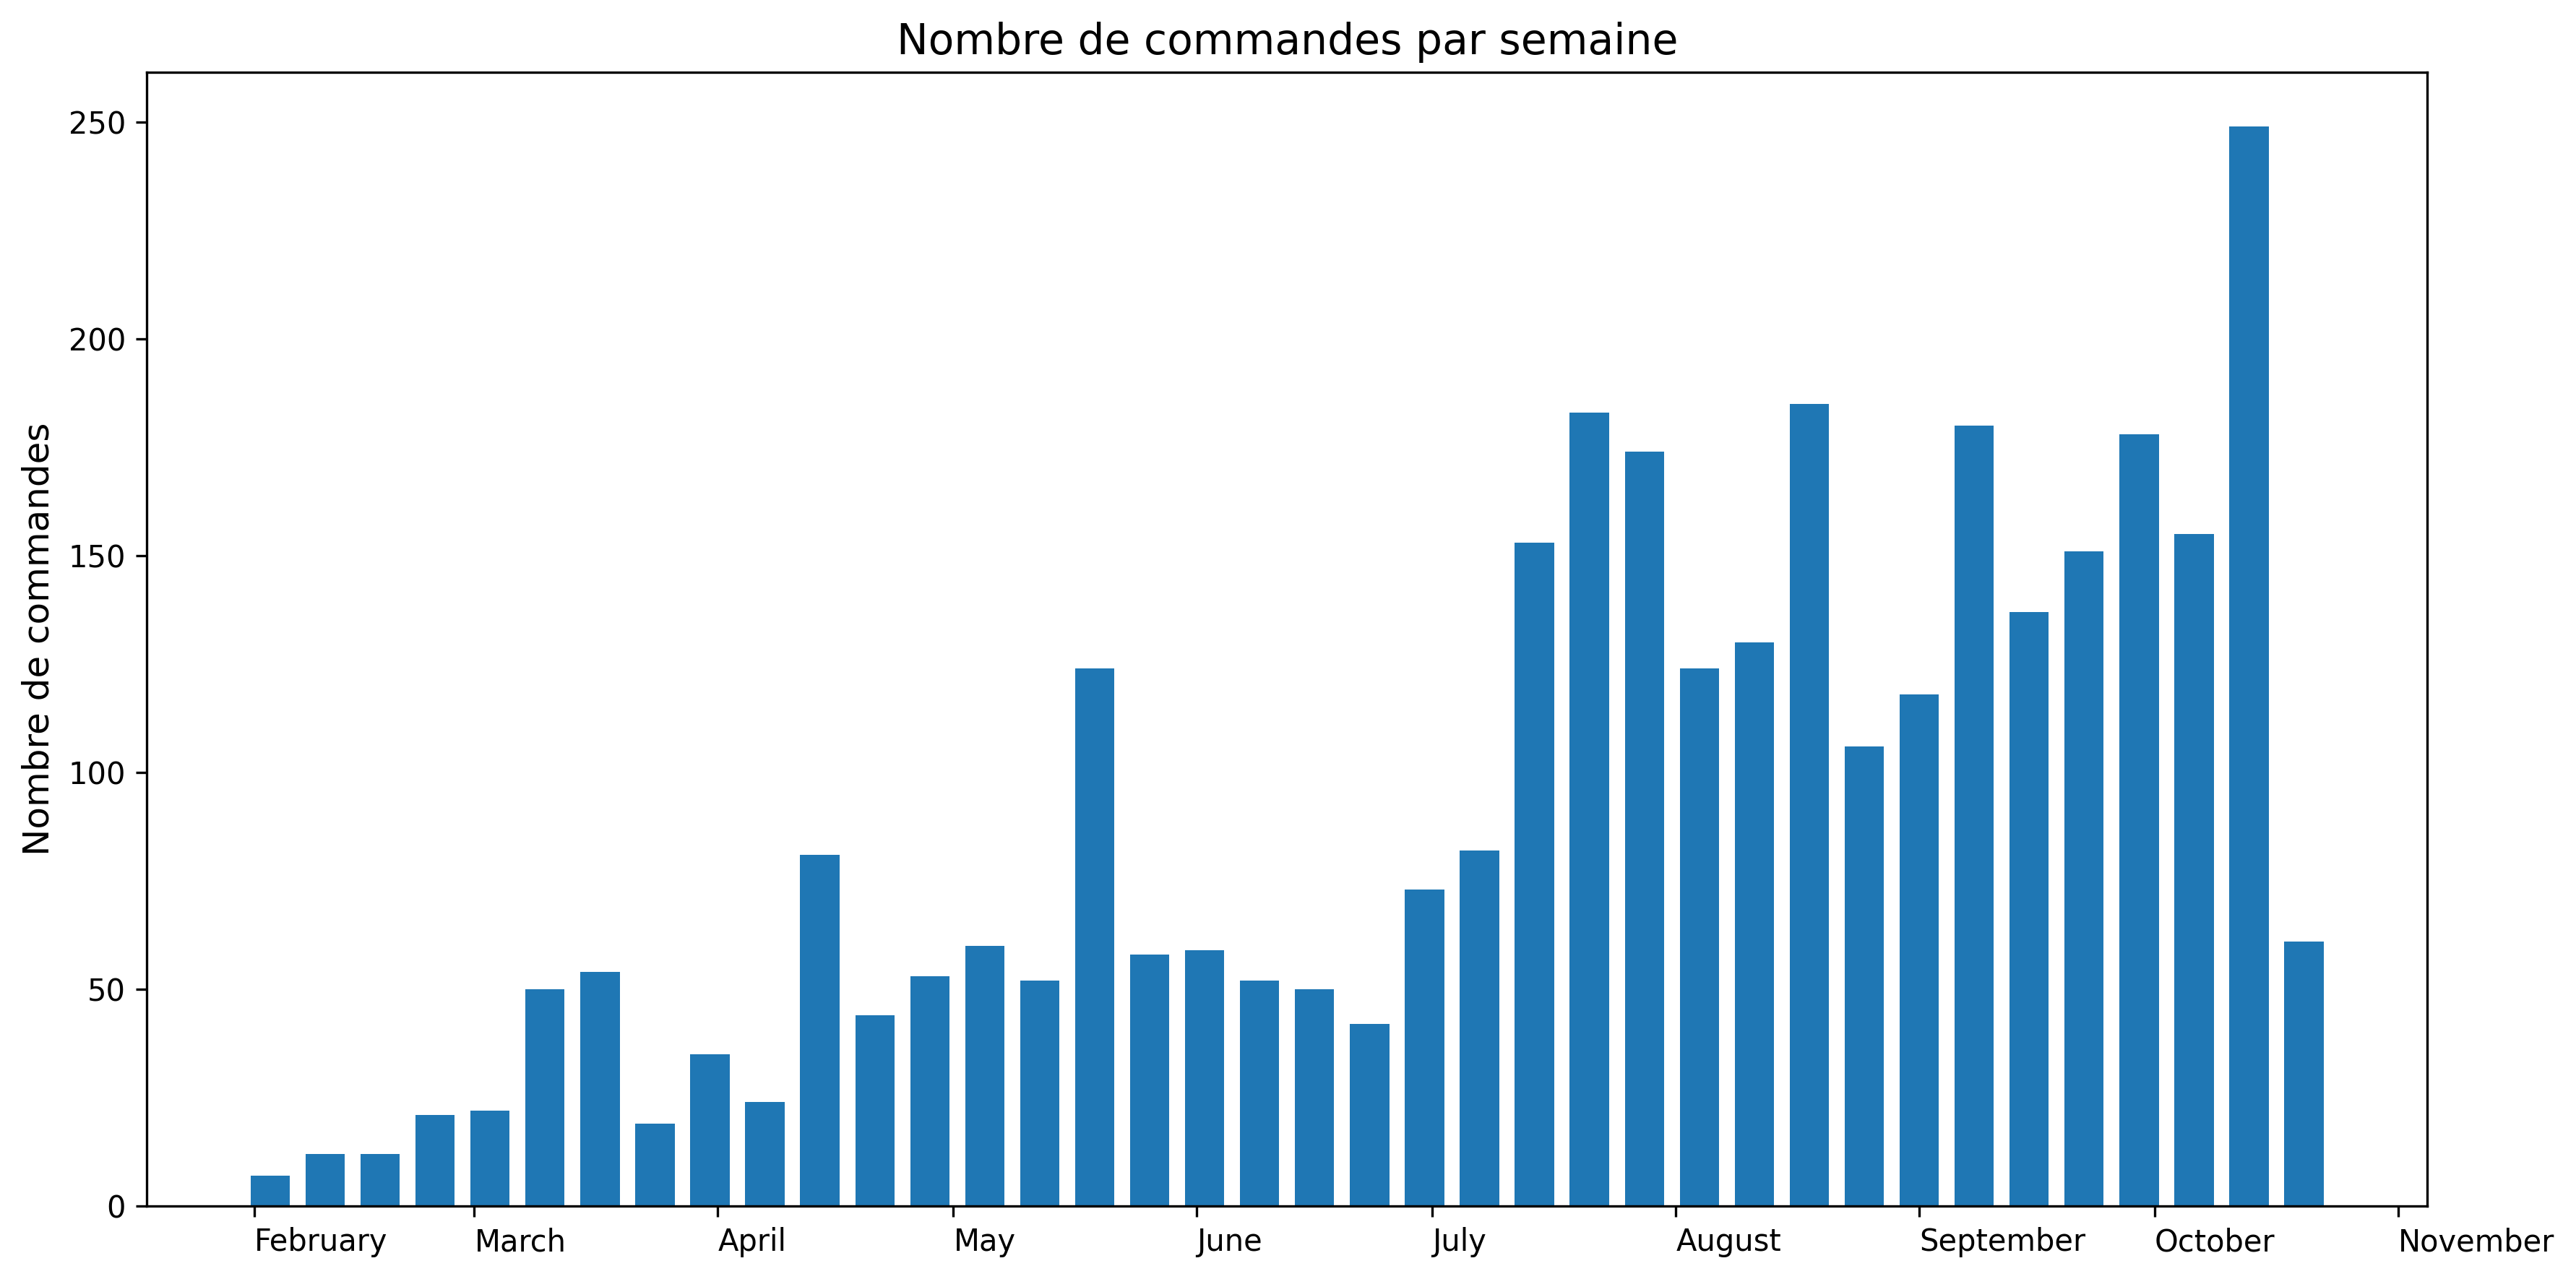

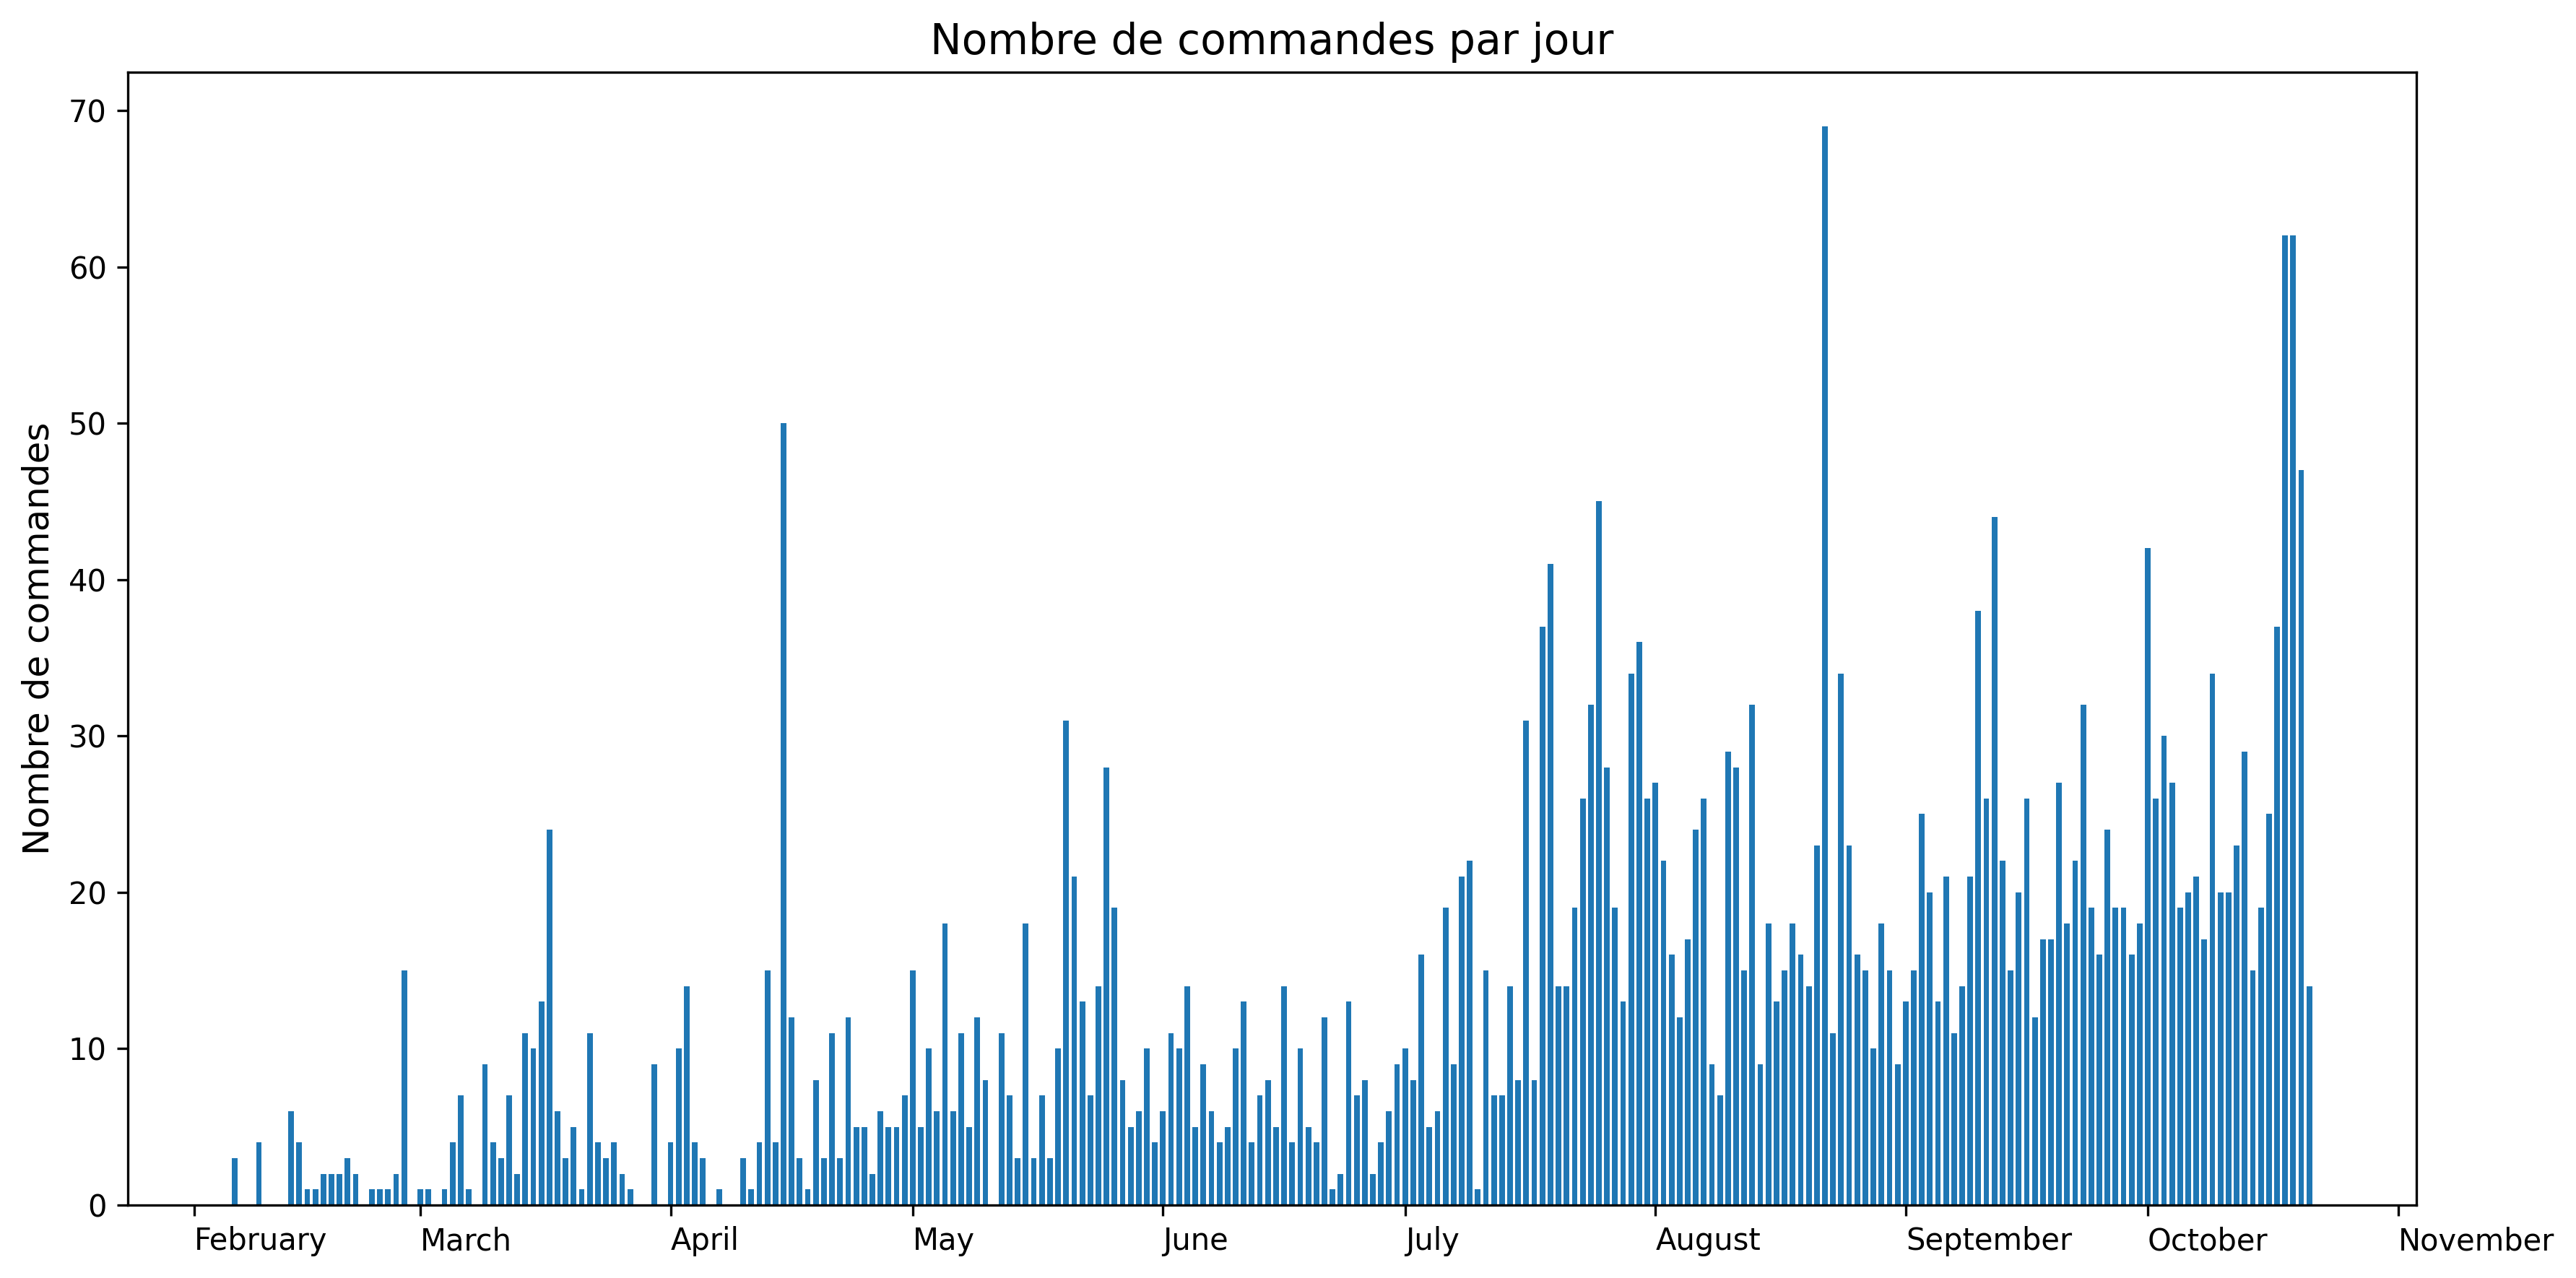

In [9]:
# Assurer que executed_at est bien un datetime
logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])

# --- Par jour ---
logs_per_day = logs_users.groupby(logs_users['executed_at'].dt.date).size()

# --- Par semaine ---
logs_users['week'] = logs_users['executed_at'].dt.to_period('W')
logs_per_week = logs_users.groupby('week').size()

# --- Par mois ---
logs_users['month'] = logs_users['executed_at'].dt.to_period('M')
logs_per_month = logs_users.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)



# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
###ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()




## utilisation des commandes tout le monde

C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\4148849298.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs['week'] = logs['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\4148849298.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs['month'] = logs['executed_at'].dt.to_period('M')


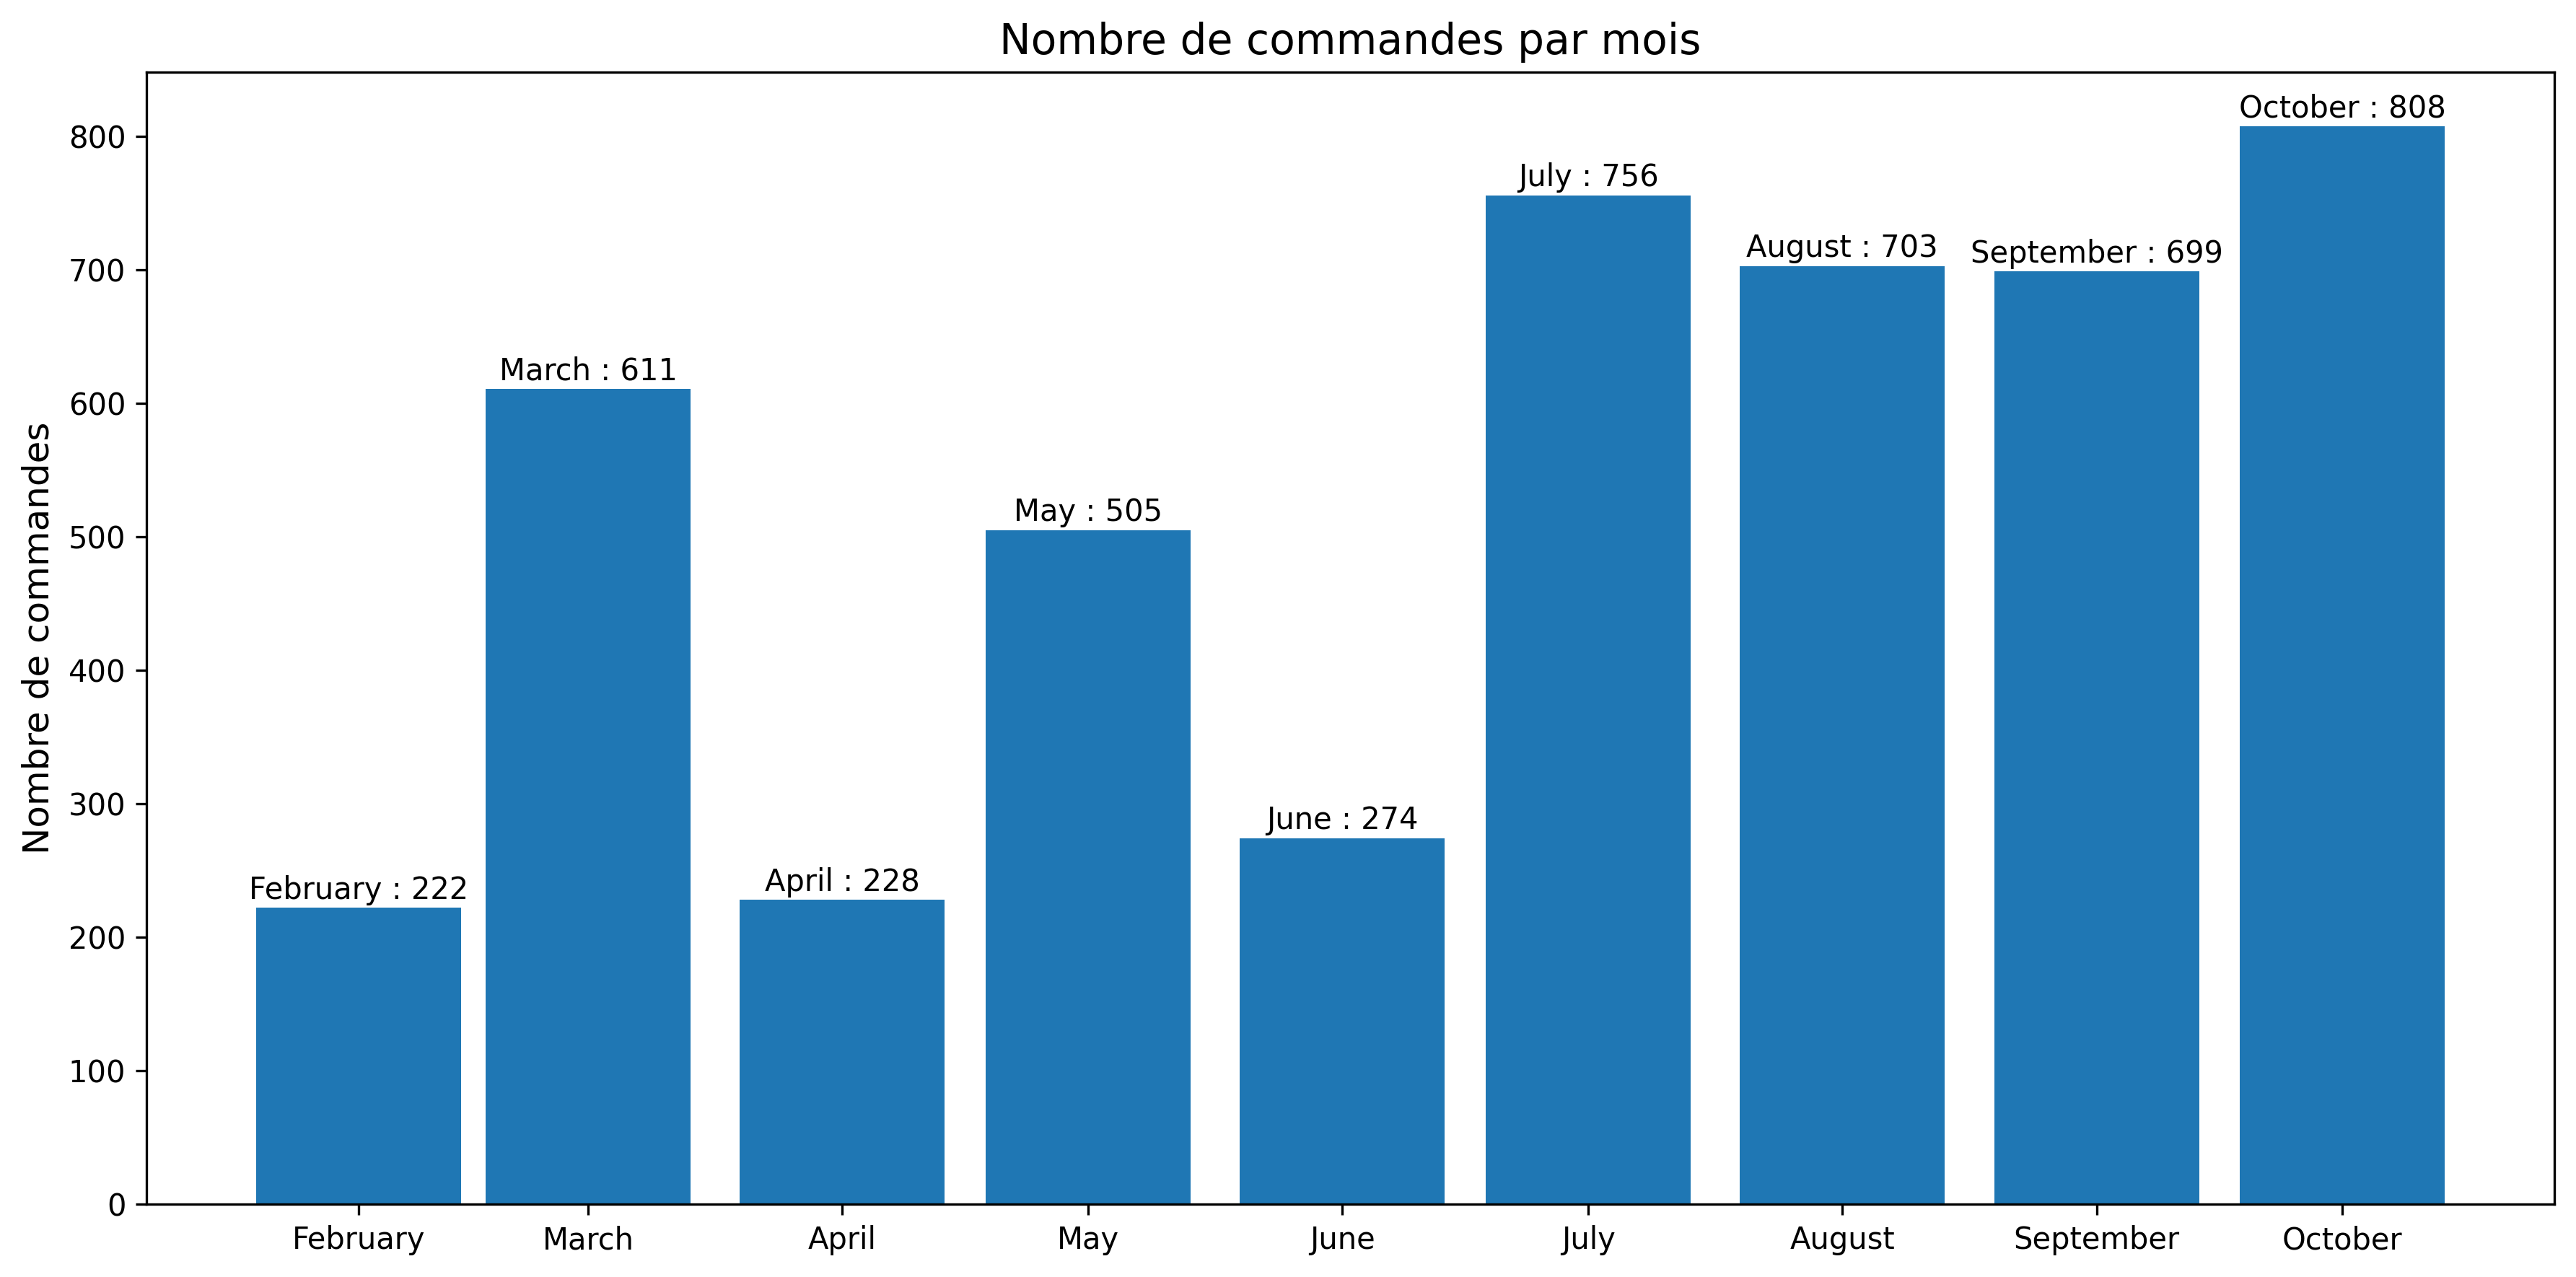

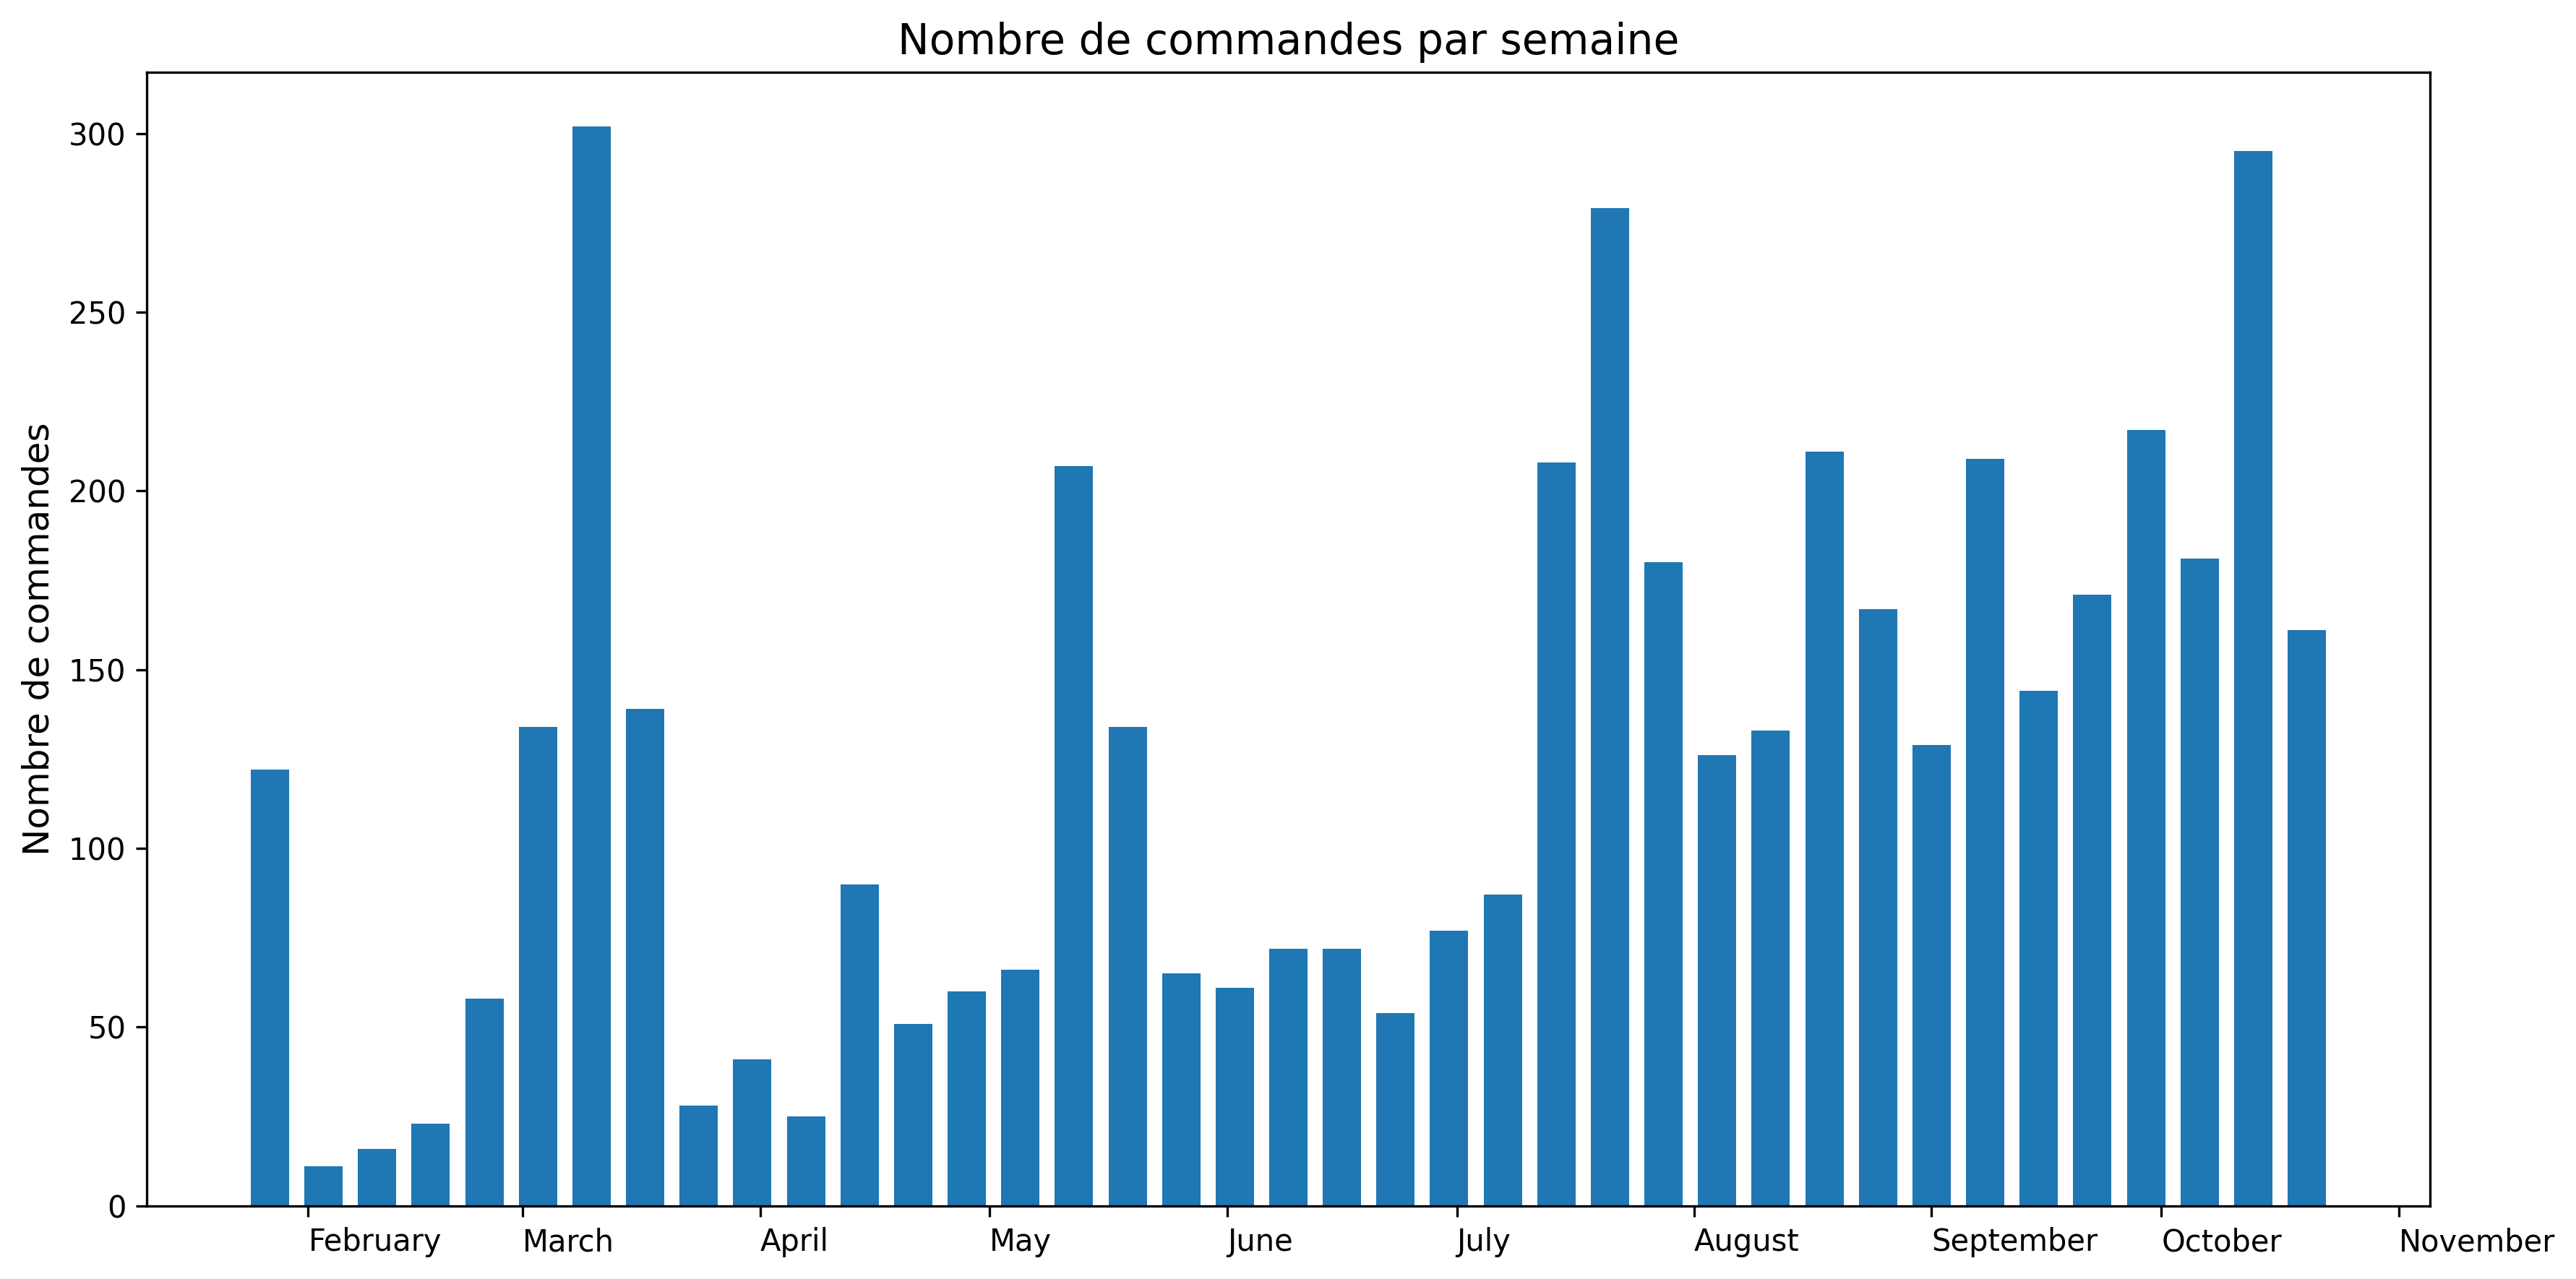

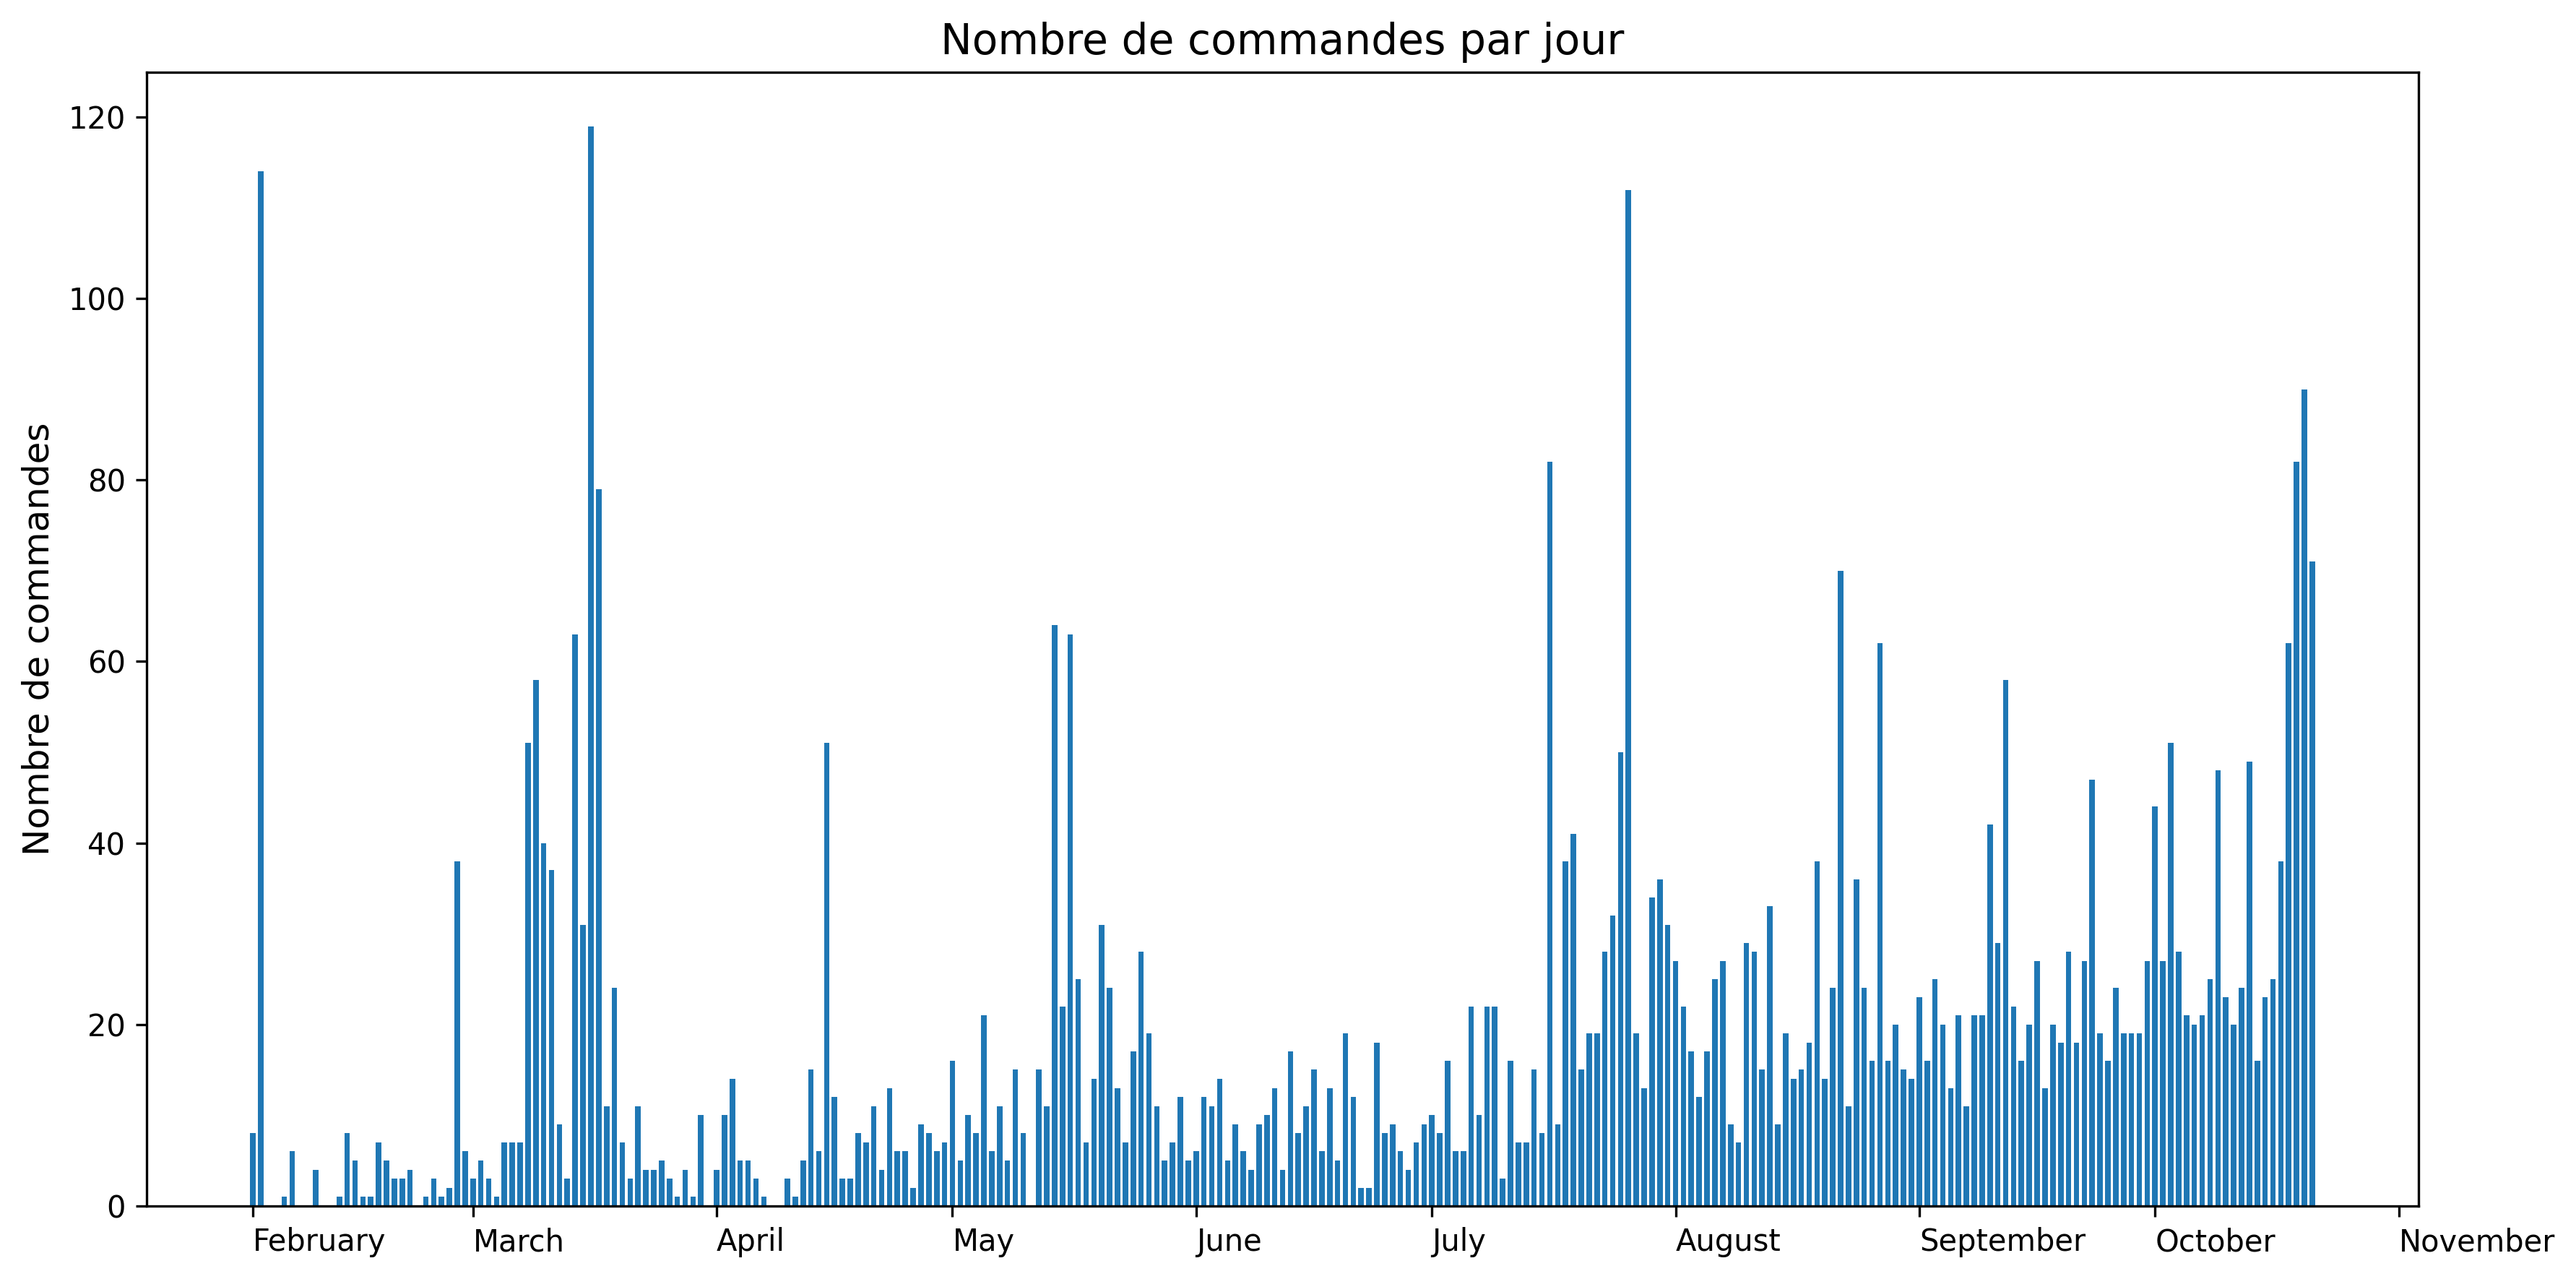

In [10]:

# Assurer que executed_at est bien un datetime
logs['executed_at'] = pd.to_datetime(logs['executed_at'])

# --- Par jour ---
logs_per_day = logs.groupby(logs['executed_at'].dt.date).size()

# --- Par semaine ---
logs['week'] = logs['executed_at'].dt.to_period('W')
logs_per_week = logs.groupby('week').size()

# --- Par mois ---
logs['month'] = logs['executed_at'].dt.to_period('M')
logs_per_month = logs.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)

# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()





## utilisation des commandes warp

C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\1793532722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_warp['executed_at'] = pd.to_datetime(logs_warp['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\1793532722.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_warp['week'] = logs_warp['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\1793532722.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-

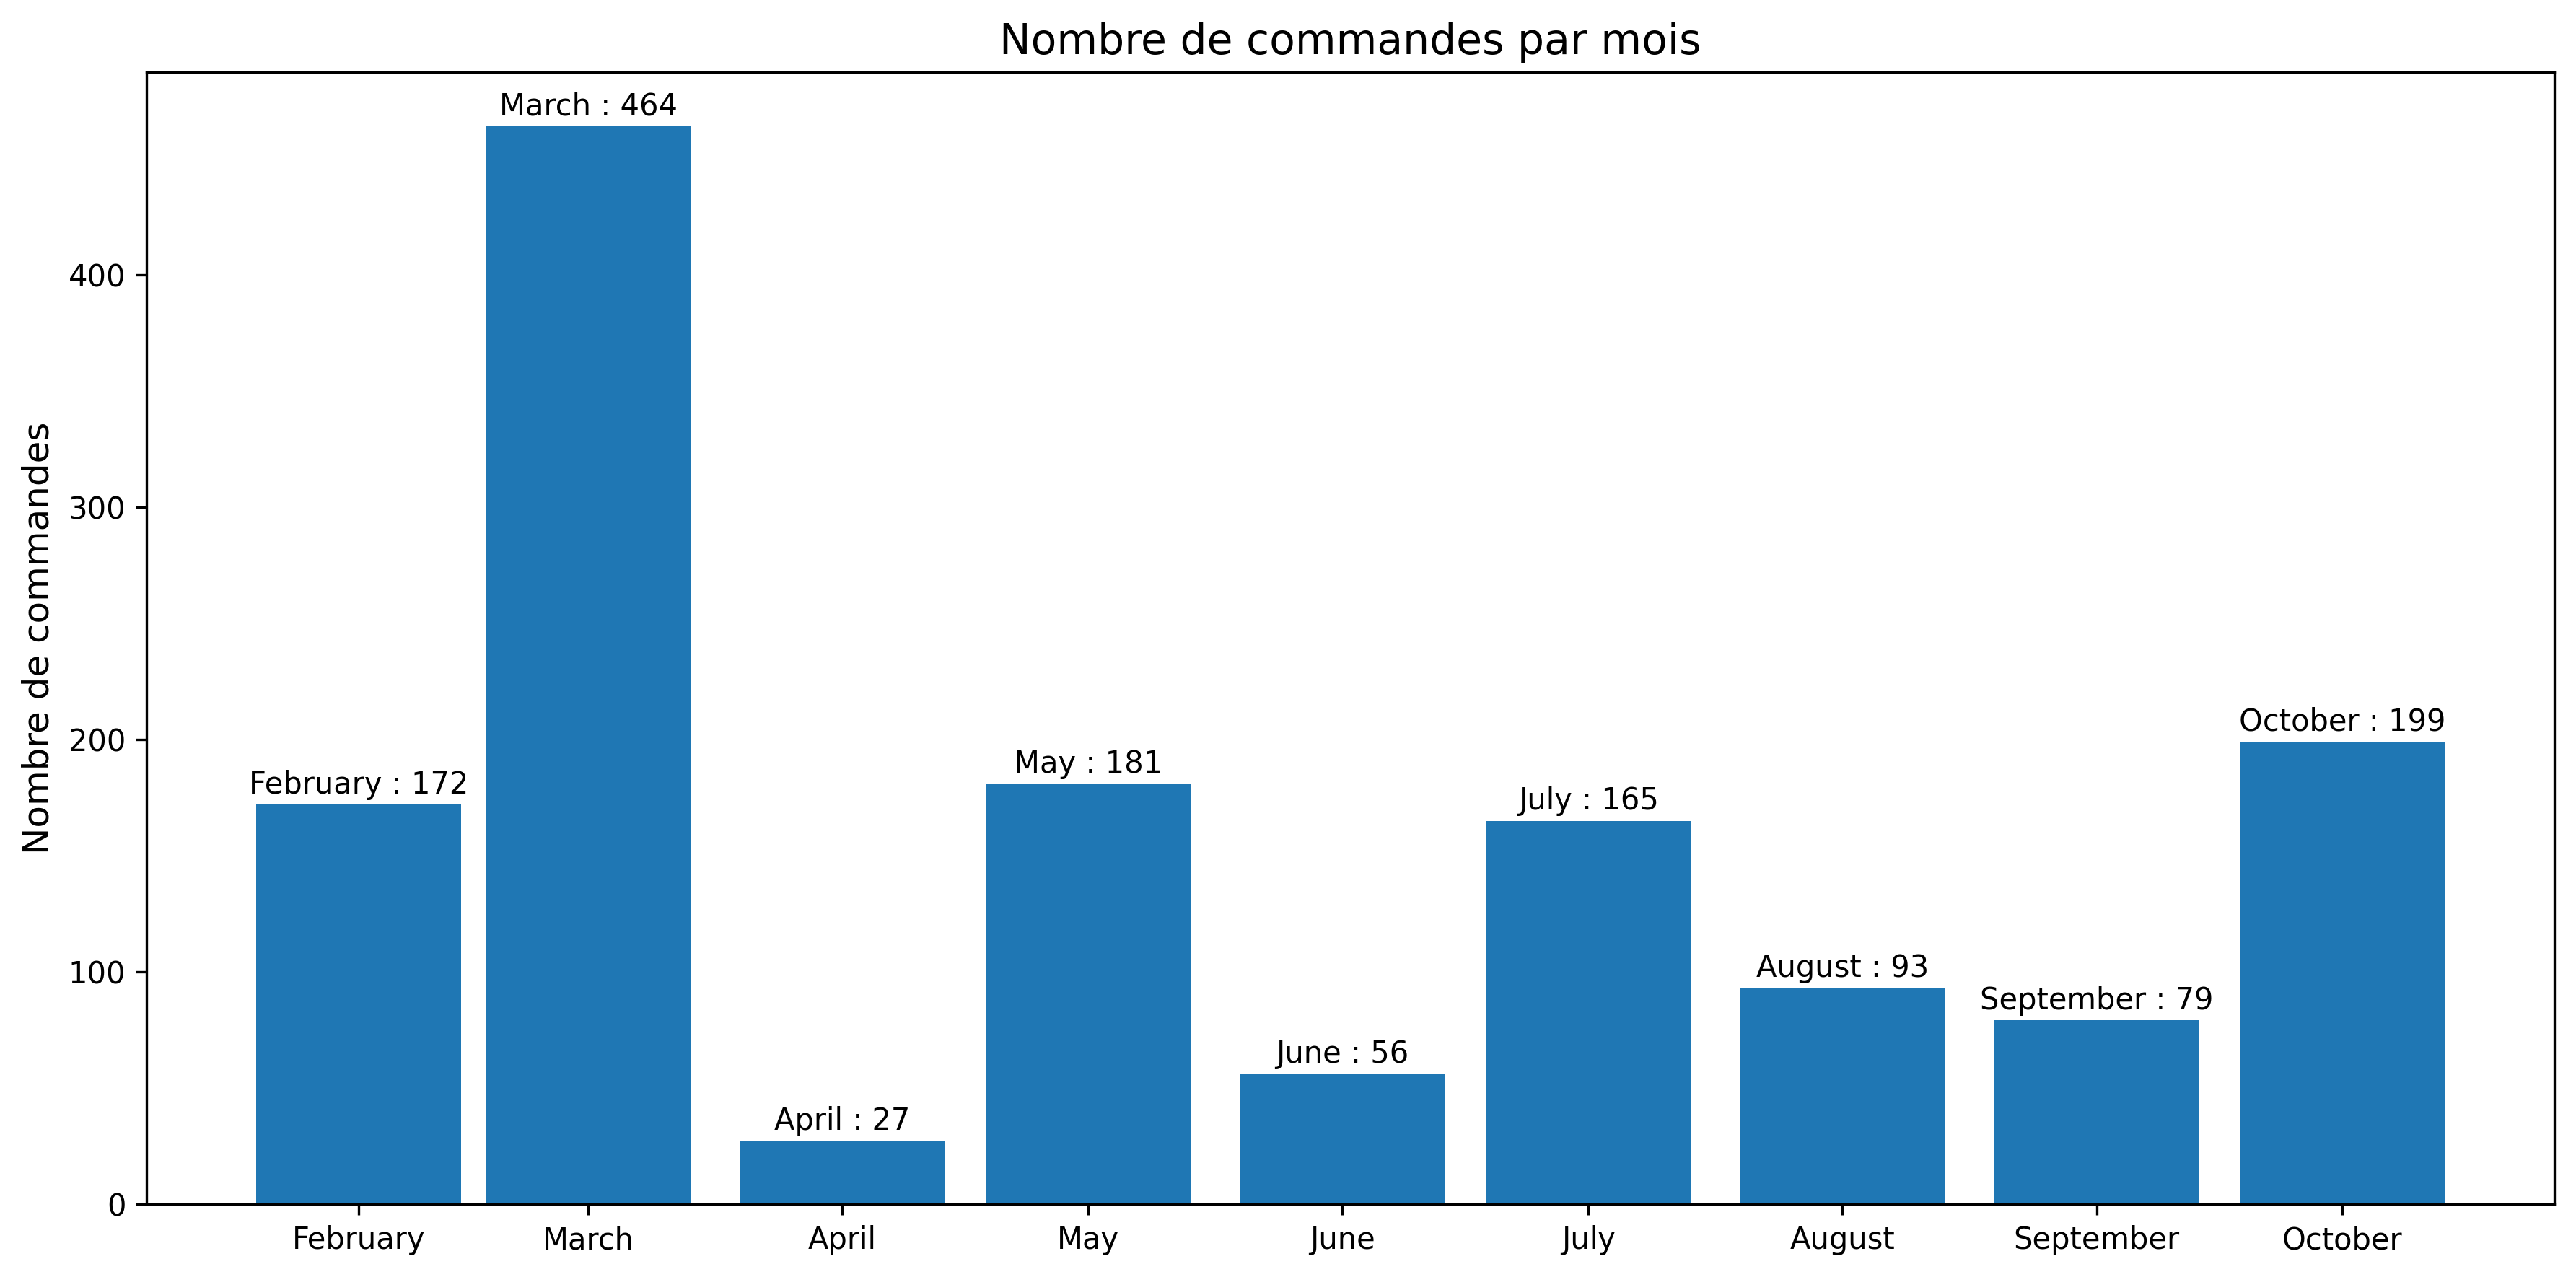

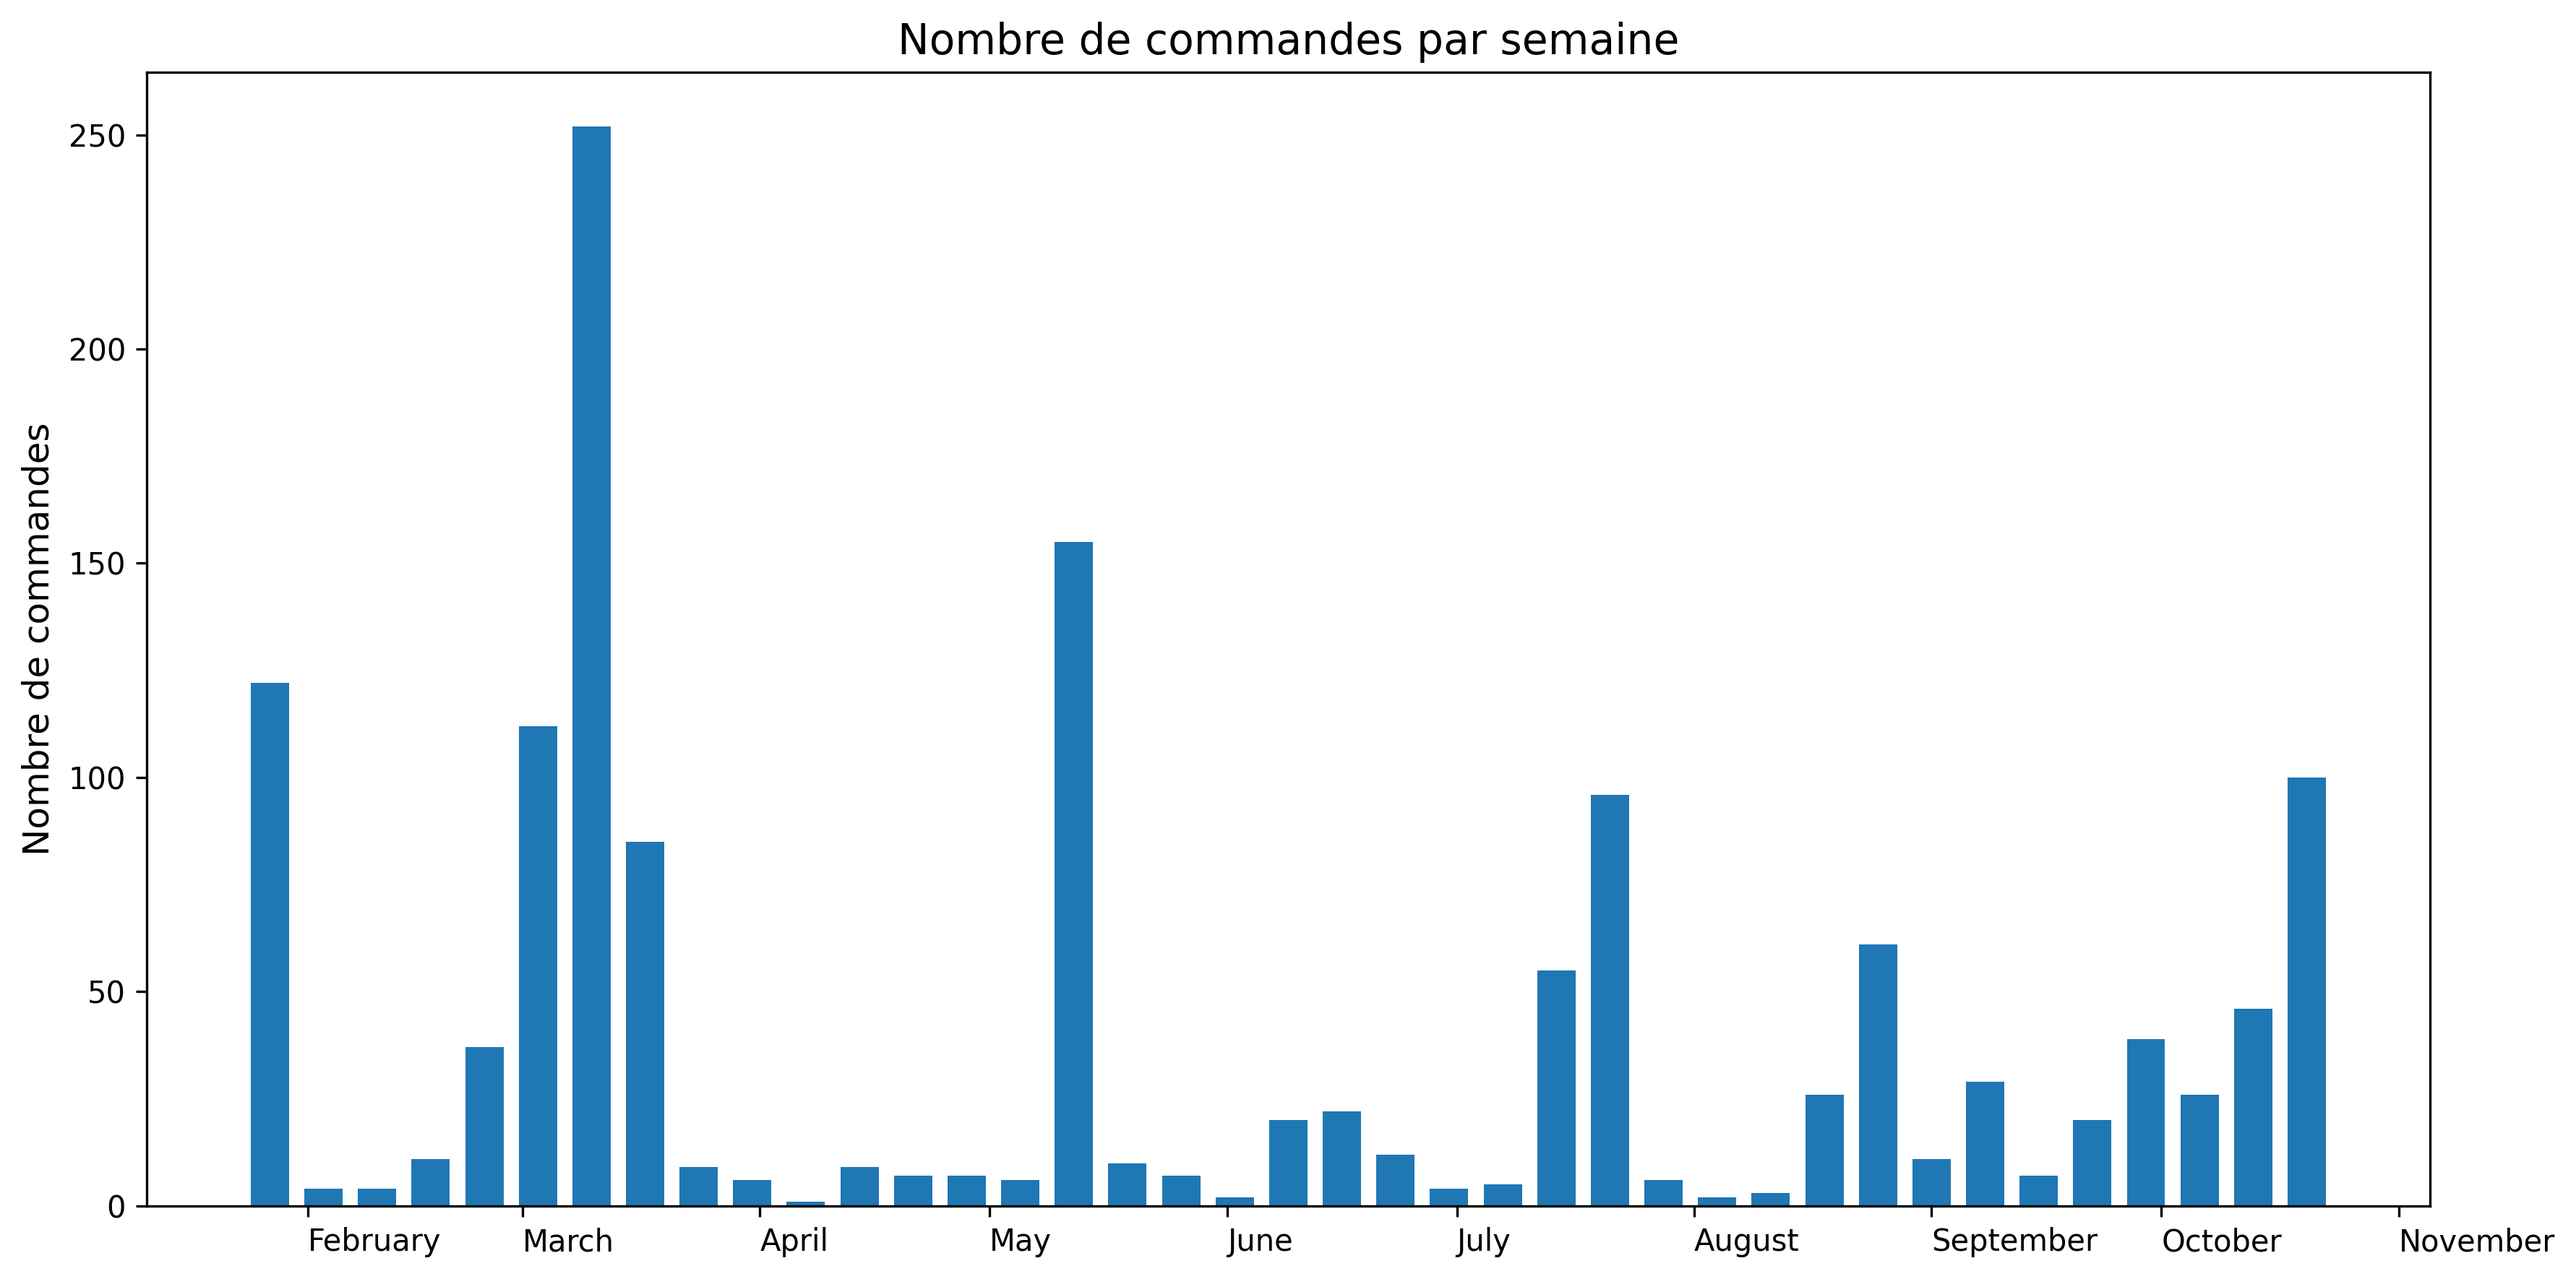

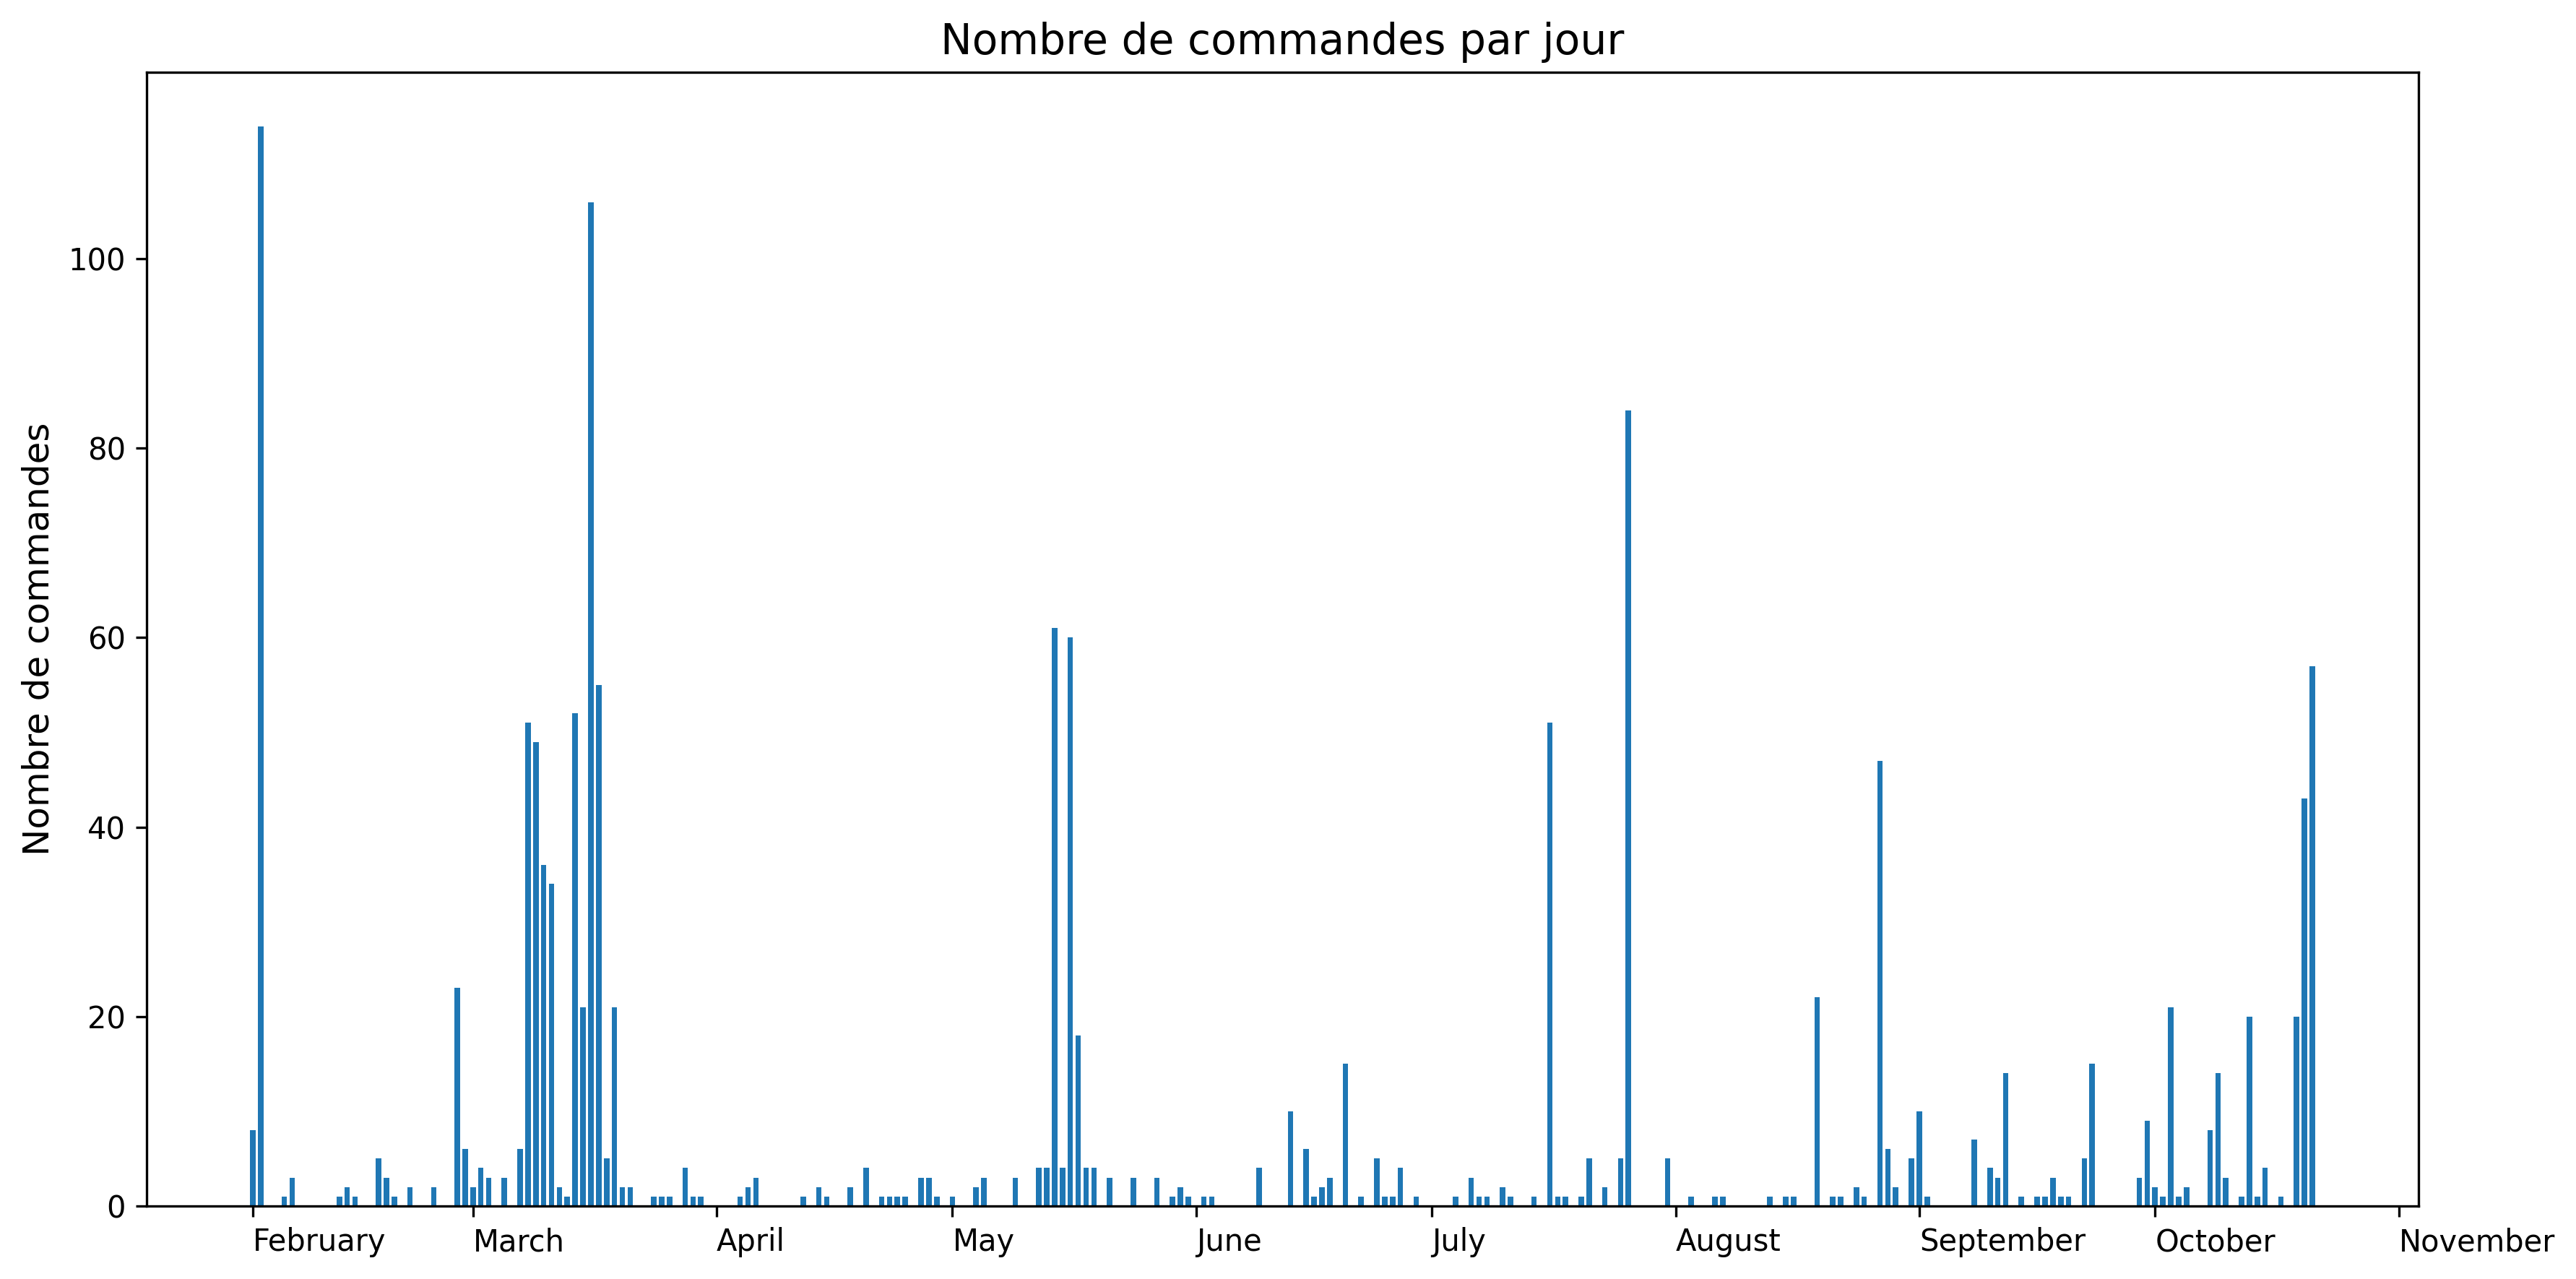

In [11]:

# Assurer que executed_at est bien un datetime
logs_warp['executed_at'] = pd.to_datetime(logs_warp['executed_at'])

# --- Par jour ---
logs_per_day = logs_warp.groupby(logs_warp['executed_at'].dt.date).size()

# --- Par semaine ---
logs_warp['week'] = logs_warp['executed_at'].dt.to_period('W')
logs_per_week = logs_warp.groupby('week').size()

# --- Par mois ---
logs_warp['month'] = logs_warp['executed_at'].dt.to_period('M')
logs_per_month = logs_warp.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)

# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()




# nombre de serveurs et utilisateurs ayant >10 commandes

In [12]:
logs_per_user = logs_users.groupby("user_name")["id"].count().sort_values(ascending=False)
print("nombre d'utilisateurs :",len(logs_per_user))
print("nombre d'utilisateurs ayant fait plus de 3 commandes :",len([logs_per_user.index[i] for i in range(len(logs_per_user)) if logs_per_user.iloc[i]>3]))
print("classement des plus gros utilisateurs du bot en nombre de commandes utilisées:")

rang=1
for usr in logs_per_user.iloc[:10].index:
    nb_cmd=logs_per_user[usr]
    print(f" - {rang}. @{usr} : {nb_cmd}")
    rang+=1
    

nombre d'utilisateurs : 533
nombre d'utilisateurs ayant fait plus de 3 commandes : 249
classement des plus gros utilisateurs du bot en nombre de commandes utilisées:
 - 1. @joao1784 : 76
 - 2. @.grybz : 65
 - 3. @klaudrr : 50
 - 4. @kymoh_ : 43
 - 5. @ilydan : 38
 - 6. @cedp : 37
 - 7. @toonsi93_ : 36
 - 8. @heartgamer. : 35
 - 9. @anyway3350 : 33
 - 10. @heny0514 : 33


In [13]:
logs_per_server = logs_users.groupby("guild_name")["id"].count().sort_values(ascending=False)
print("nombre de serveurs :",len(logs_per_server))
print("nombre de serveurs ayant fait plus de 3 commandes :",len([logs_per_server.index[i] for i in range(len(logs_per_server)) if logs_per_server.iloc[i]>3]))
print("classement des plus gros utilisateurs du bot en nombre de commandes utilisées:")

rang=1
for usr in logs_per_server.iloc[:10].index:
    nb_cmd=logs_per_server[usr]
    print(f" - {rang}. {usr} : {nb_cmd}")
    rang+=1

nombre de serveurs : 97
nombre de serveurs ayant fait plus de 3 commandes : 71
classement des plus gros utilisateurs du bot en nombre de commandes utilisées:
 - 1. Dofus Touls : 470
 - 2. La Secte : 451
 - 3. Origami : 197
 - 4. Stellar - Dofus TOUCH : 178
 - 5. Horizon : 126
 - 6. Nouveau Règne [NRV] : 109
 - 7. H O N O R E D : 107
 - 8. The-Horde : 107
 - 9. Tchiki-tchiki : 104
 - 10. Maarss Community : 97


In [14]:

def get_contrast_color(rgba):
    """
    Retourne 'white' ou 'black' selon la luminosité de la couleur RGBA.
    """
    r, g, b, _ = rgba
    # Luminosité perçue
    brightness = 0.299*r + 0.587*g + 0.114*b
    return 'white' if brightness < 0.5 else 'black'

C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\4237021991.py:100: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from current font.
  plt.tight_layout()
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\4237021991.py:100: UserWarning: Glyph 3663 (\N{THAI CHARACTER FONGMAN}) missing from current font.
  plt.tight_layout()
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\4237021991.py:100: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  plt.tight_layout()
C:\Users\Joannes\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Joannes\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3663 (\N{THAI CHARACTER FONGMAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Joannes\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabto

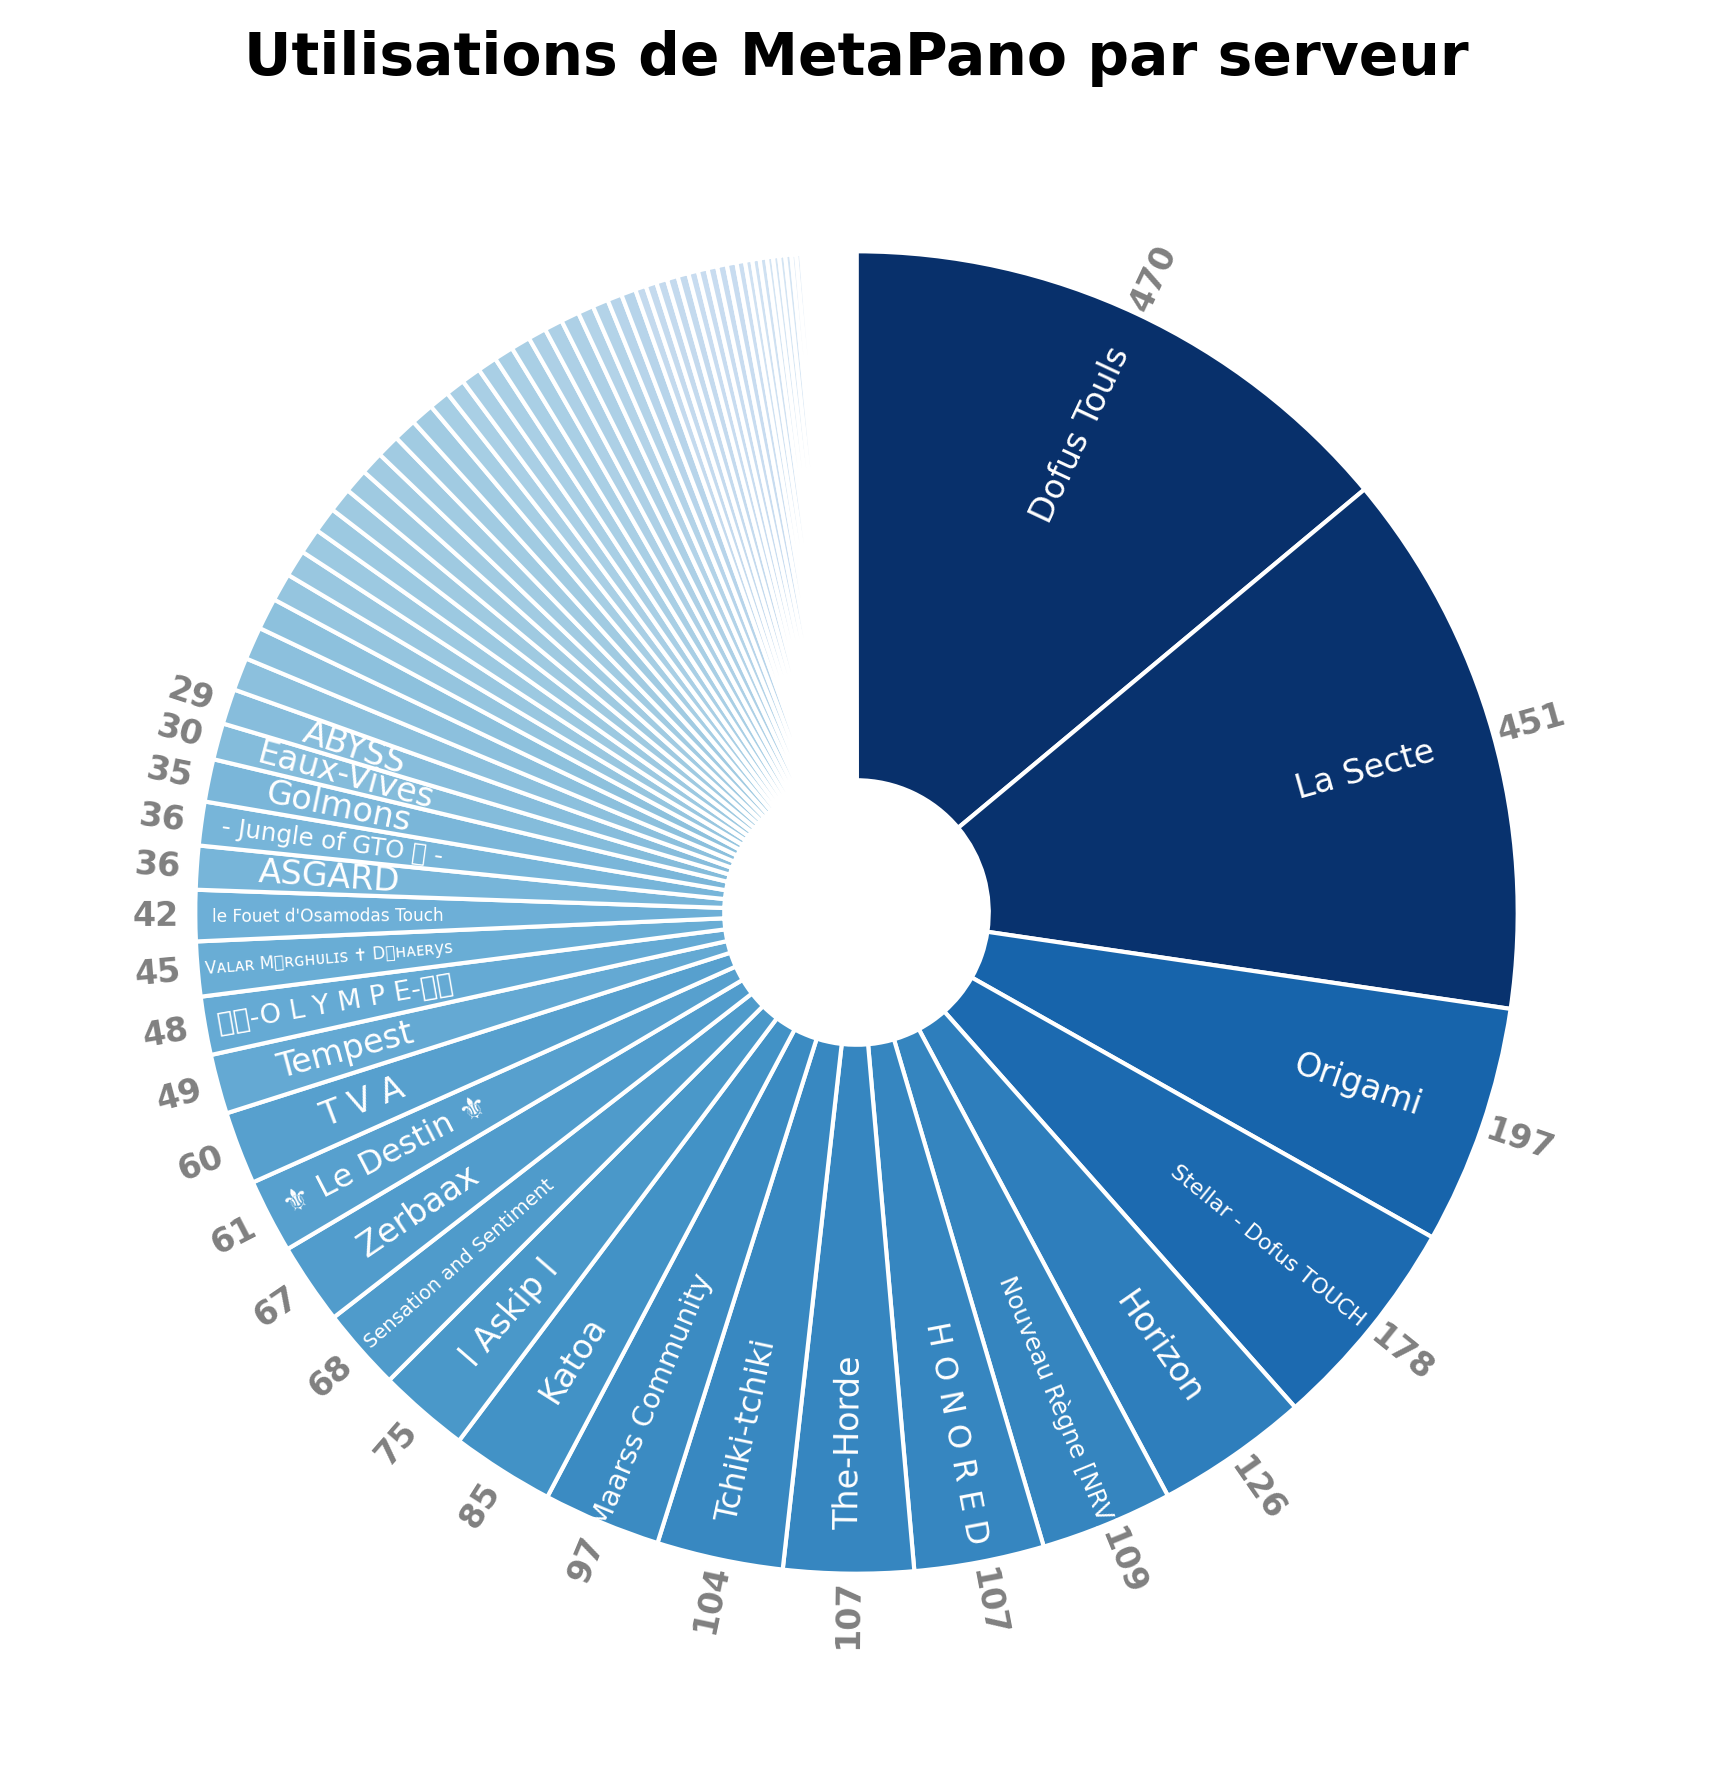

In [15]:
nb_noms_affichés=15
nb_parts=len(logs_per_server)
# colors = cm.plasma(np.linspace(0.4, 1, nb_parts))  # 0.4 évite les couleurs trop claires
# fig, ax= plt.subplots(figsize=(12,12),dpi=300)
# ax.pie(logs_per_server.iloc[:100],labels=logs_per_server.iloc[:nb_noms_affichés].index.to_list()+[""]*(nb_parts-nb_noms_affichés))

# # ----- Dégradé logarithmique -----
# log_values = np.log1p(logs_per_server.values)  # log(1 + x) pour éviter log(0)
# norm = (log_values - log_values.min()) / (log_values.max() - log_values.min())
# colors = cm.Blues(norm)    # Version 1 : dégradé logarithmique (bleu)

# ----- Dégradé racine carrée -----
# scaled_values = np.sqrt(logs_per_server.values)
# norm = (scaled_values - scaled_values.min()) / (scaled_values.max() - scaled_values.min())
# colors = cm.Blues(norm)  # ou cm.Blues_r pour inverser

# ----- Dégradé puissance perso -----
alpha = 0.15  # Plus petit = plus doux, 1 = linéaire
scaled_values = np.power(logs_per_server.values, alpha)
norm = (scaled_values - scaled_values.min()) / (scaled_values.max() - scaled_values.min())
colors = cm.Blues(norm)


available_colormaps = [
    cm.viridis,cm.viridis_r, cm.plasma,cm.plasma_r, cm.inferno, cm.inferno_r, cm.magma,cm.magma_r,
    cm.cividis,cm.cividis_r, cm.Blues, cm.Blues_r, cm.Reds, cm.Greens, cm.Purples
]
colors_list=[]
for c in available_colormaps:
    colors_list.append(c(norm))

# ===== Données =====
logs_per_server = logs_users.groupby("guild_name")["id"].count().sort_values(ascending=False)
values = logs_per_server.values
labels = logs_per_server.index

# ----- Fonction pour dessiner le pie chart -----
def plot_pie(data, colors, title):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

    wedges, _ = ax.pie(
        data,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.8, edgecolor='white')
    )

    for i, wedge in enumerate(wedges):        
        theta1, theta2 = wedge.theta1, wedge.theta2
        mid_angle = np.deg2rad((theta1 + theta2) / 2)

        # Rayon de base
        r_label = 0.80  # Pour le nom du serveur
        r_value = 1.06  # Pour la valeur, légèrement plus proche du centre
    
        # Coordonnées
        x_label = r_label * np.cos(mid_angle)
        y_label = r_label * np.sin(mid_angle)
        x_value = r_value * np.cos(mid_angle)
        y_value = r_value * np.sin(mid_angle)

        max_chars = 12 # seuil de longueur

        # ----- Rotation correcte du label -----
        angle = (theta1 + theta2) / 2 - 90
        if angle < -180:
            angle += 180  # éviter les textes à l'envers

        # Taille de la part
        angle_size = theta2 - theta1

        textcolor = get_contrast_color(colors[i])

        # Affiche le texte seulement si la part est assez grande
        if angle_size > 3:  # seuil en degrés
            ax.text(
                x_label, y_label,                
                labels[i],
                ha='center', va='center',
                rotation=angle + 90,  # alignement le long du rayon
                rotation_mode='default',
                # fontsize=9,
                fontsize = max(4, 8 - 0.3 * max(0, len(labels[i]) - max_chars)),
                color="w"
            )
                    # ---- Valeur numérique ----
            ax.text(
                x_value, y_value,
                str(values[i]),
                ha='center', va='center',
                rotation=angle + 90,
                rotation_mode='default',
                fontsize=8,
                color="grey",
                fontweight='bold'
            )

    ax.set_title(title, fontsize=14, fontweight='bold',pad=1)
    plt.tight_layout()
    plt.show()

# 'top', 'bottom', '', 'baseline', 'center_baseline'
# plot_pie(logs_per_server, colors_log, "Répartition des commandes par serveur (Dégradé logarithmique)")
# plot_pie(logs_per_server, colors_plasma, "Répartition des commandes par serveur (Colormap Plasma)")
# for c in colors_list:
#     plot_pie(logs_per_server,c,"Répartition des commandes par serveur")
plot_pie(logs_per_server,colors,"Utilisations de MetaPano par serveur")

In [16]:
logs_per_server

guild_name
Dofus Touls              470
La Secte                 451
Origami                  197
Stellar - Dofus TOUCH    178
Horizon                  126
                        ... 
Semper Fidelis             1
Serveur de Draken          1
Serveur de Gueux           1
Serveur test               1
                           1
Name: id, Length: 97, dtype: int64

# nombre d'utilisateurs/serveurs par mois

C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\2838007625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\2838007625.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(logs_users['executed_at'].dt.to_period('M'))['user_name']
C:\Users\Joannes\AppData\Local\Temp\ipykernel_5900\2838007625.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(logs_users['executed_at'].dt.to_period('M'))['guild_name']


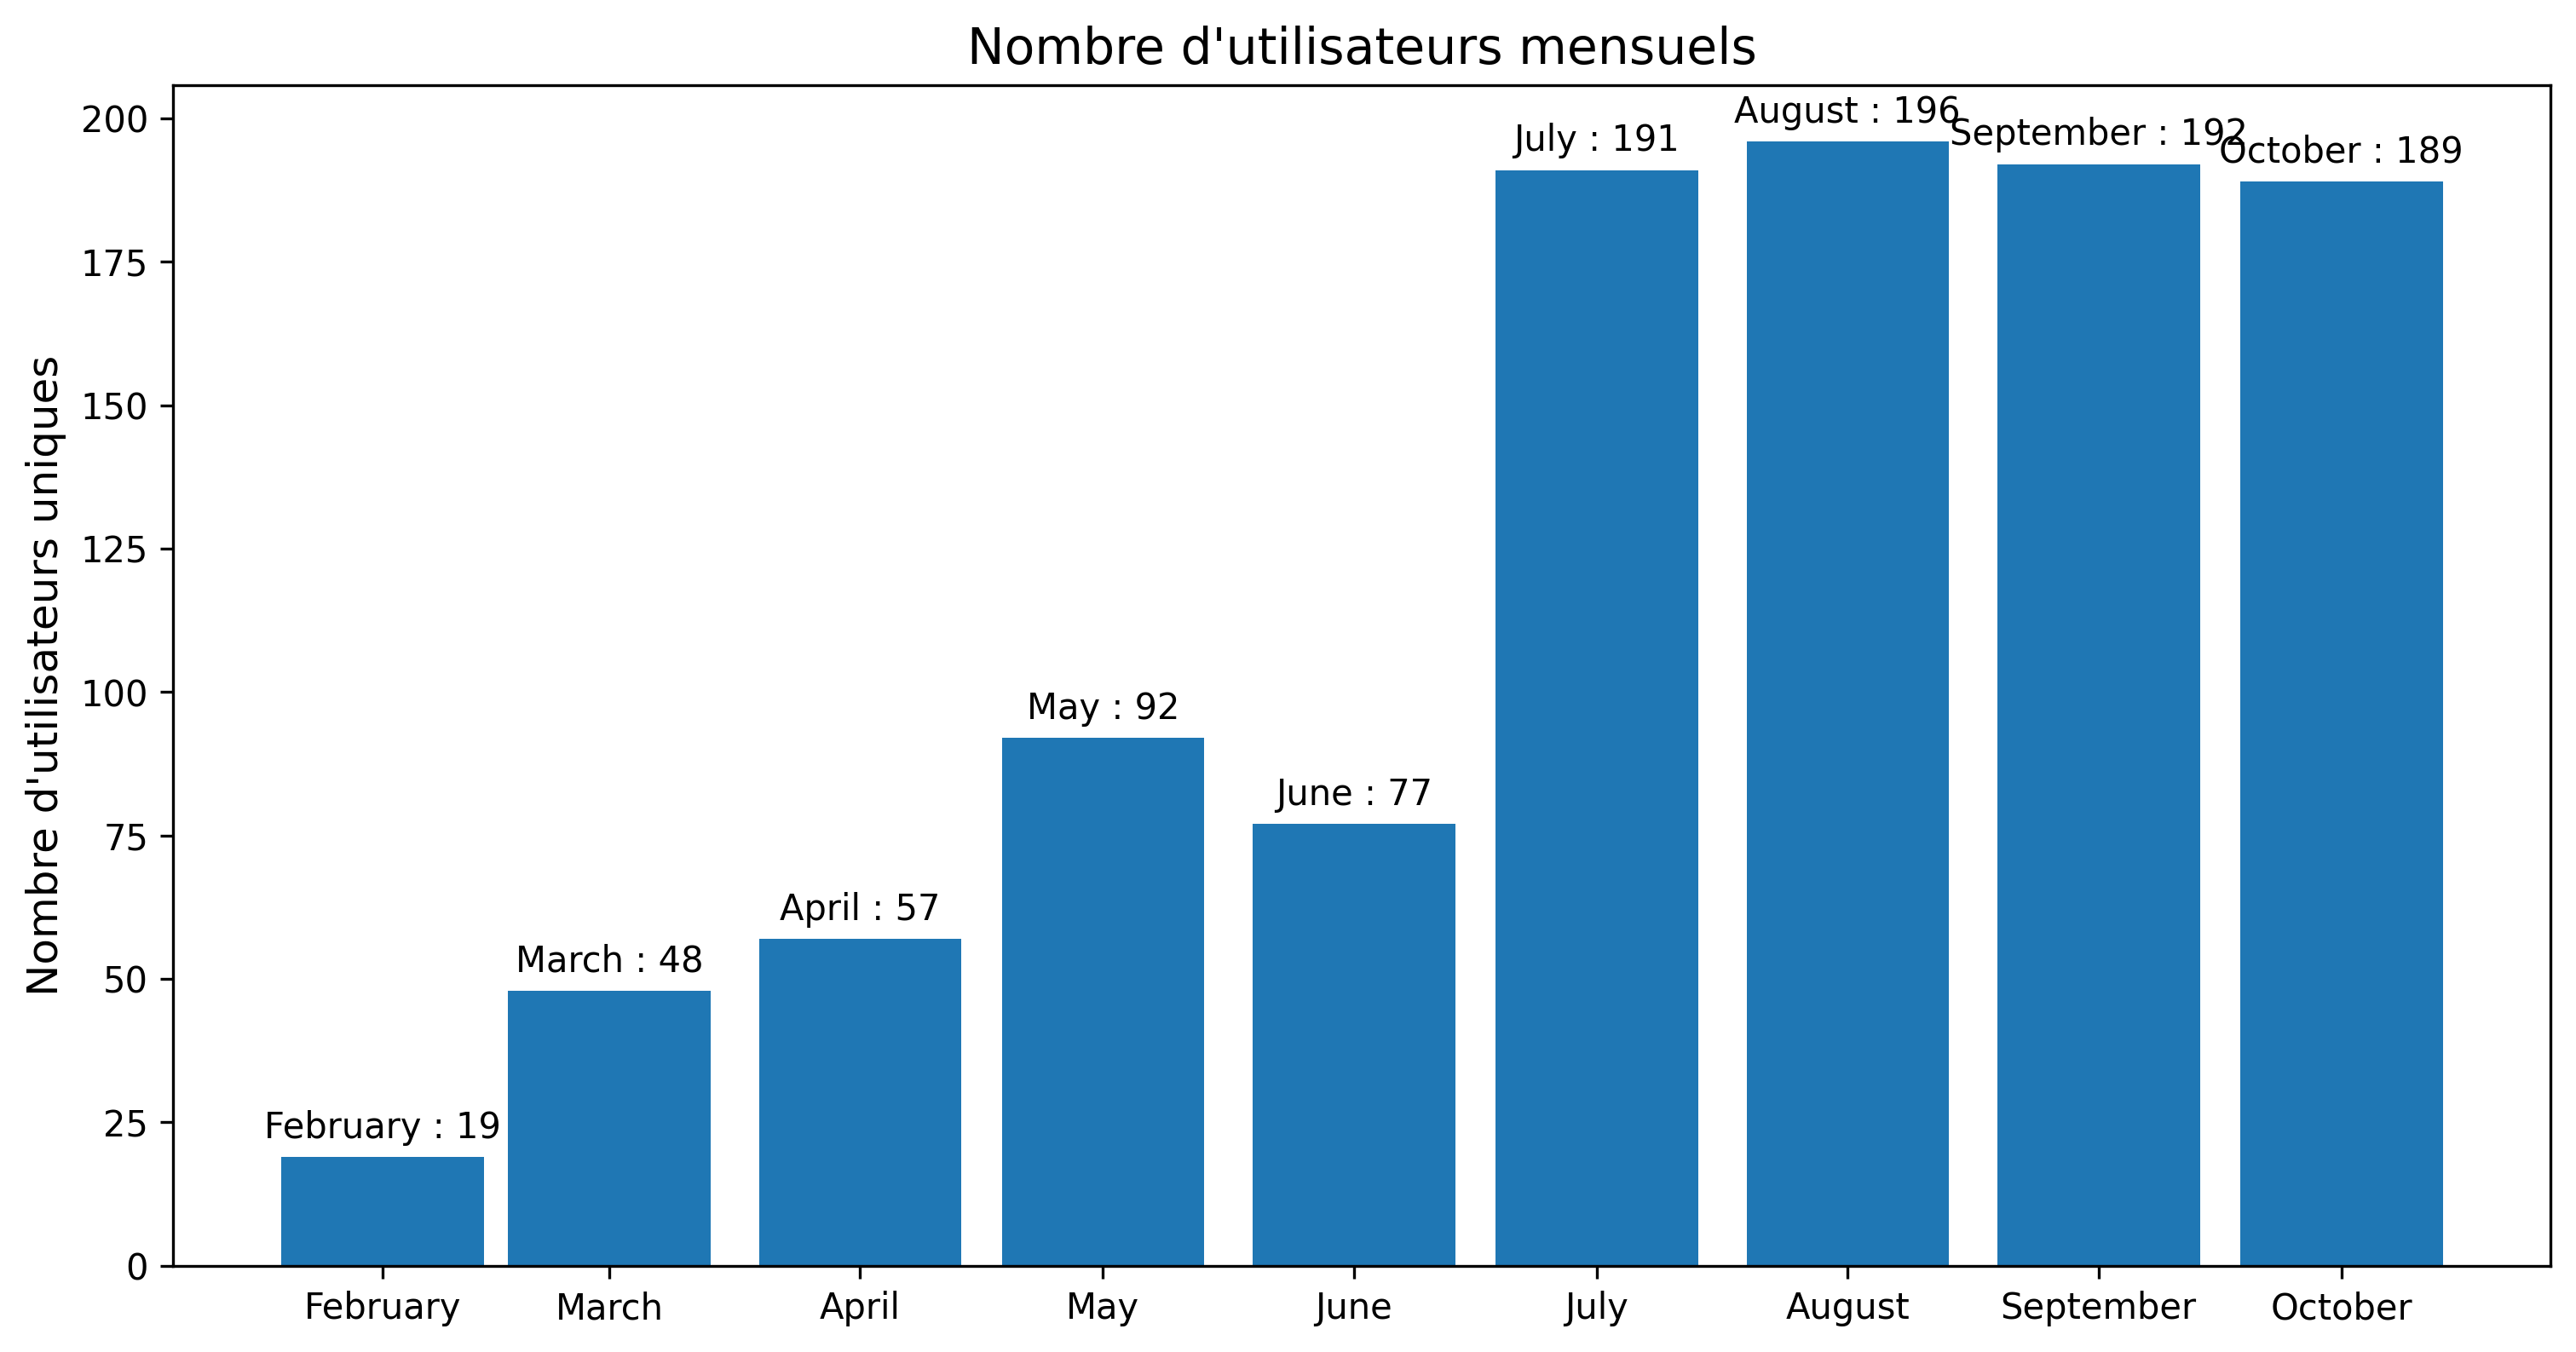

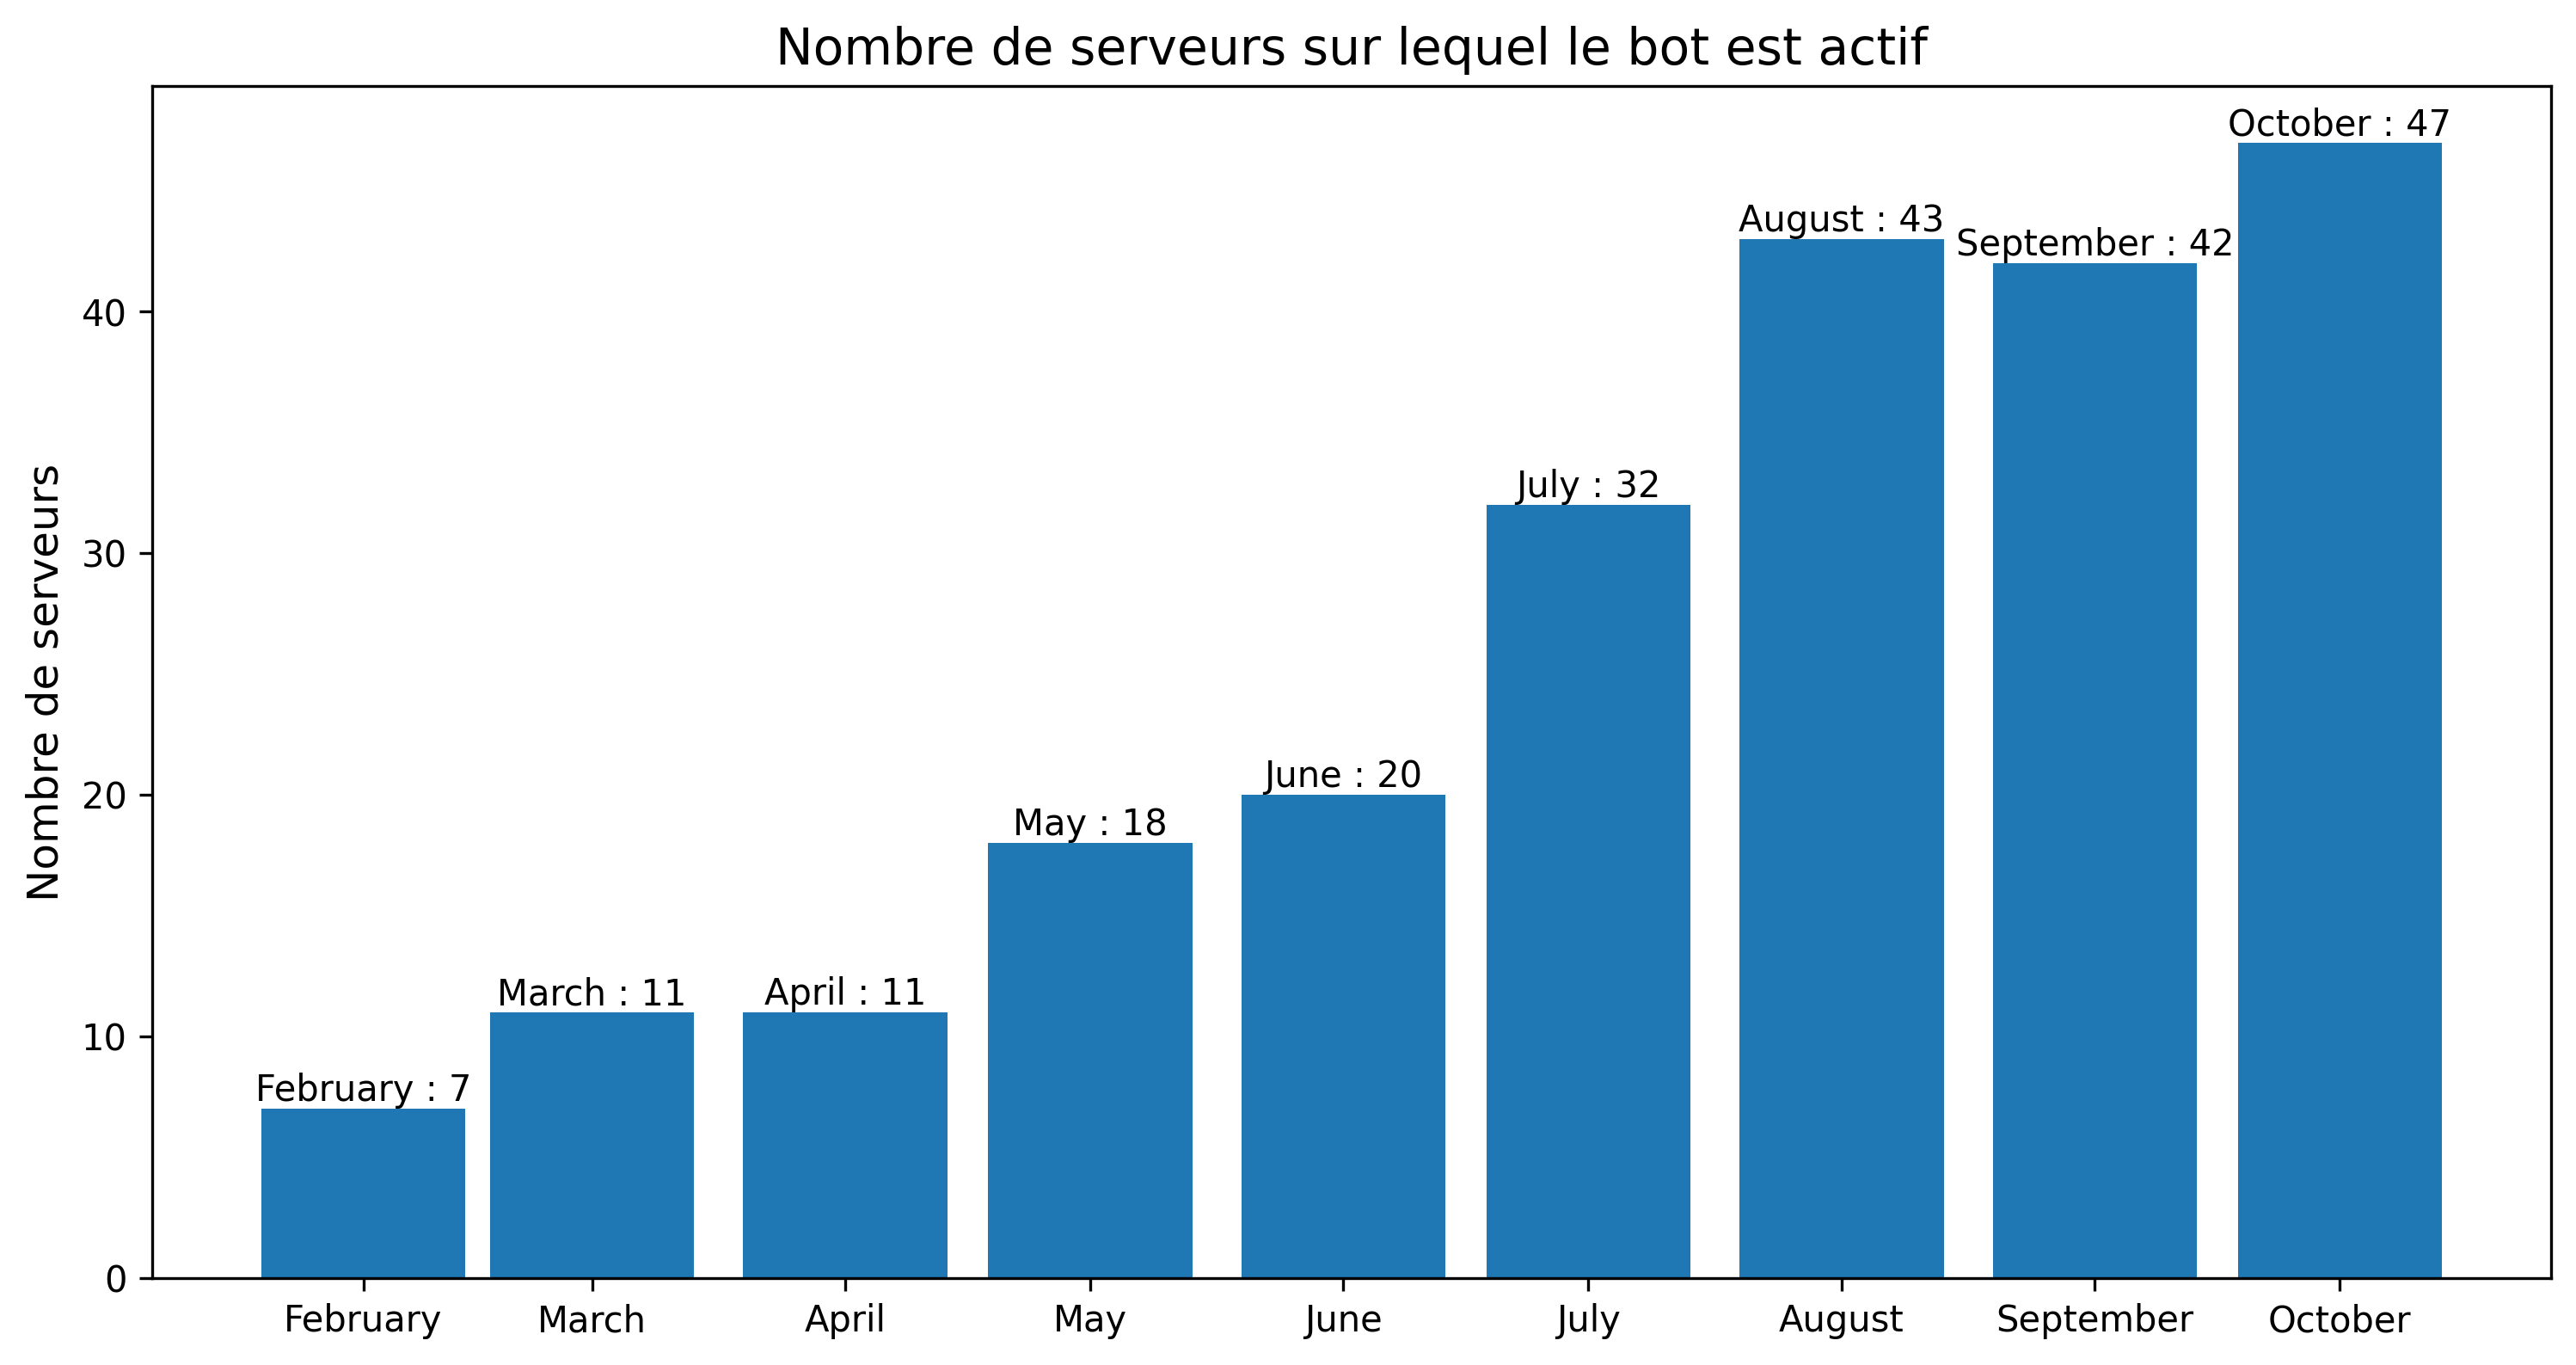

In [17]:
# S'assurer que executed_at est bien en datetime
logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])

# Grouper par mois et compter les utilisateurs uniques
unique_users_per_month = (
    logs_users
    .groupby(logs_users['executed_at'].dt.to_period('M'))['user_name']
    .nunique()
)
# Convertir l'index Period -> Timestamp pour l'affichage sur le graphique
unique_users_per_month.index = unique_users_per_month.index.to_timestamp()

# Grouper par mois et compter les serveurs uniques
unique_guilds_per_month = (
    logs_users
    .groupby(logs_users['executed_at'].dt.to_period('M'))['guild_name']
    .nunique()
)
# Convertir l'index Period -> Timestamp pour l'affichage sur le graphique
unique_guilds_per_month.index = unique_guilds_per_month.index.to_timestamp()
# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)



# --- Par mois ---
if not isinstance(unique_users_per_month.index, pd.DatetimeIndex):
    unique_users_per_month.index = unique_users_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(unique_users_per_month.index, unique_users_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre d'utilisateurs mensuels", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre d'utilisateurs uniques", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(unique_users_per_month)):
    ax.text(
        unique_users_per_month.index[i],               # X = la vraie date
        unique_users_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{unique_users_per_month.index[i].strftime('%B')} : {unique_users_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )


# --- Par mois ---
if not isinstance(unique_guilds_per_month.index, pd.DatetimeIndex):
    unique_guilds_per_month.index = unique_guilds_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(unique_guilds_per_month.index, unique_guilds_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de serveurs sur lequel le bot est actif", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de serveurs", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(unique_guilds_per_month)):
    ax.text(
        unique_guilds_per_month.index[i],               # X = la vraie date
        unique_guilds_per_month.iloc[i],                # Y = hauteur de la barre
        f"{unique_guilds_per_month.index[i].strftime('%B')} : {unique_guilds_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

# arguments les plus utilisés

In [18]:
# top 10 des éléments, classement des classes

logs["arguments_dict"] = logs["arguments"].apply(
    lambda x: json.loads(x) if pd.notnull(x) else {}
)
logs["classe"] = logs["arguments_dict"].apply(lambda d: d.get("classe")).str.lower()
logs["element"] = logs["arguments_dict"].apply(lambda d: d.get("element")).str.lower()

classe_counts = logs["classe"].value_counts(dropna=True)
classe_counts_filtered = classe_counts[classe_counts > 10]
print(classe_counts_filtered)
element_counts = logs["element"].value_counts(dropna=True)
element_counts_filtered = element_counts[element_counts > 10]
print(element_counts_filtered)


classe
ecaflip      259
cra          162
eniripsa     158
sacrieur     157
pandawa      157
steamer      147
zobal        145
iop          143
sadida       139
enutrof      128
feca         127
xelor        121
sram         109
osamodas     106
roublard      91
eliotrope     16
vide          12
Name: count, dtype: int64
element
terre                              539
eau                                307
feu                                284
air                                245
dopou                              185
terre eau                           52
cc                                  49
do pou                              48
eau air                             42
feu eau                             42
terre feu                           37
eau feu                             36
terre cc                            35
multi                               31
soin                                30
feu air                             30
terre air                           30
pp     

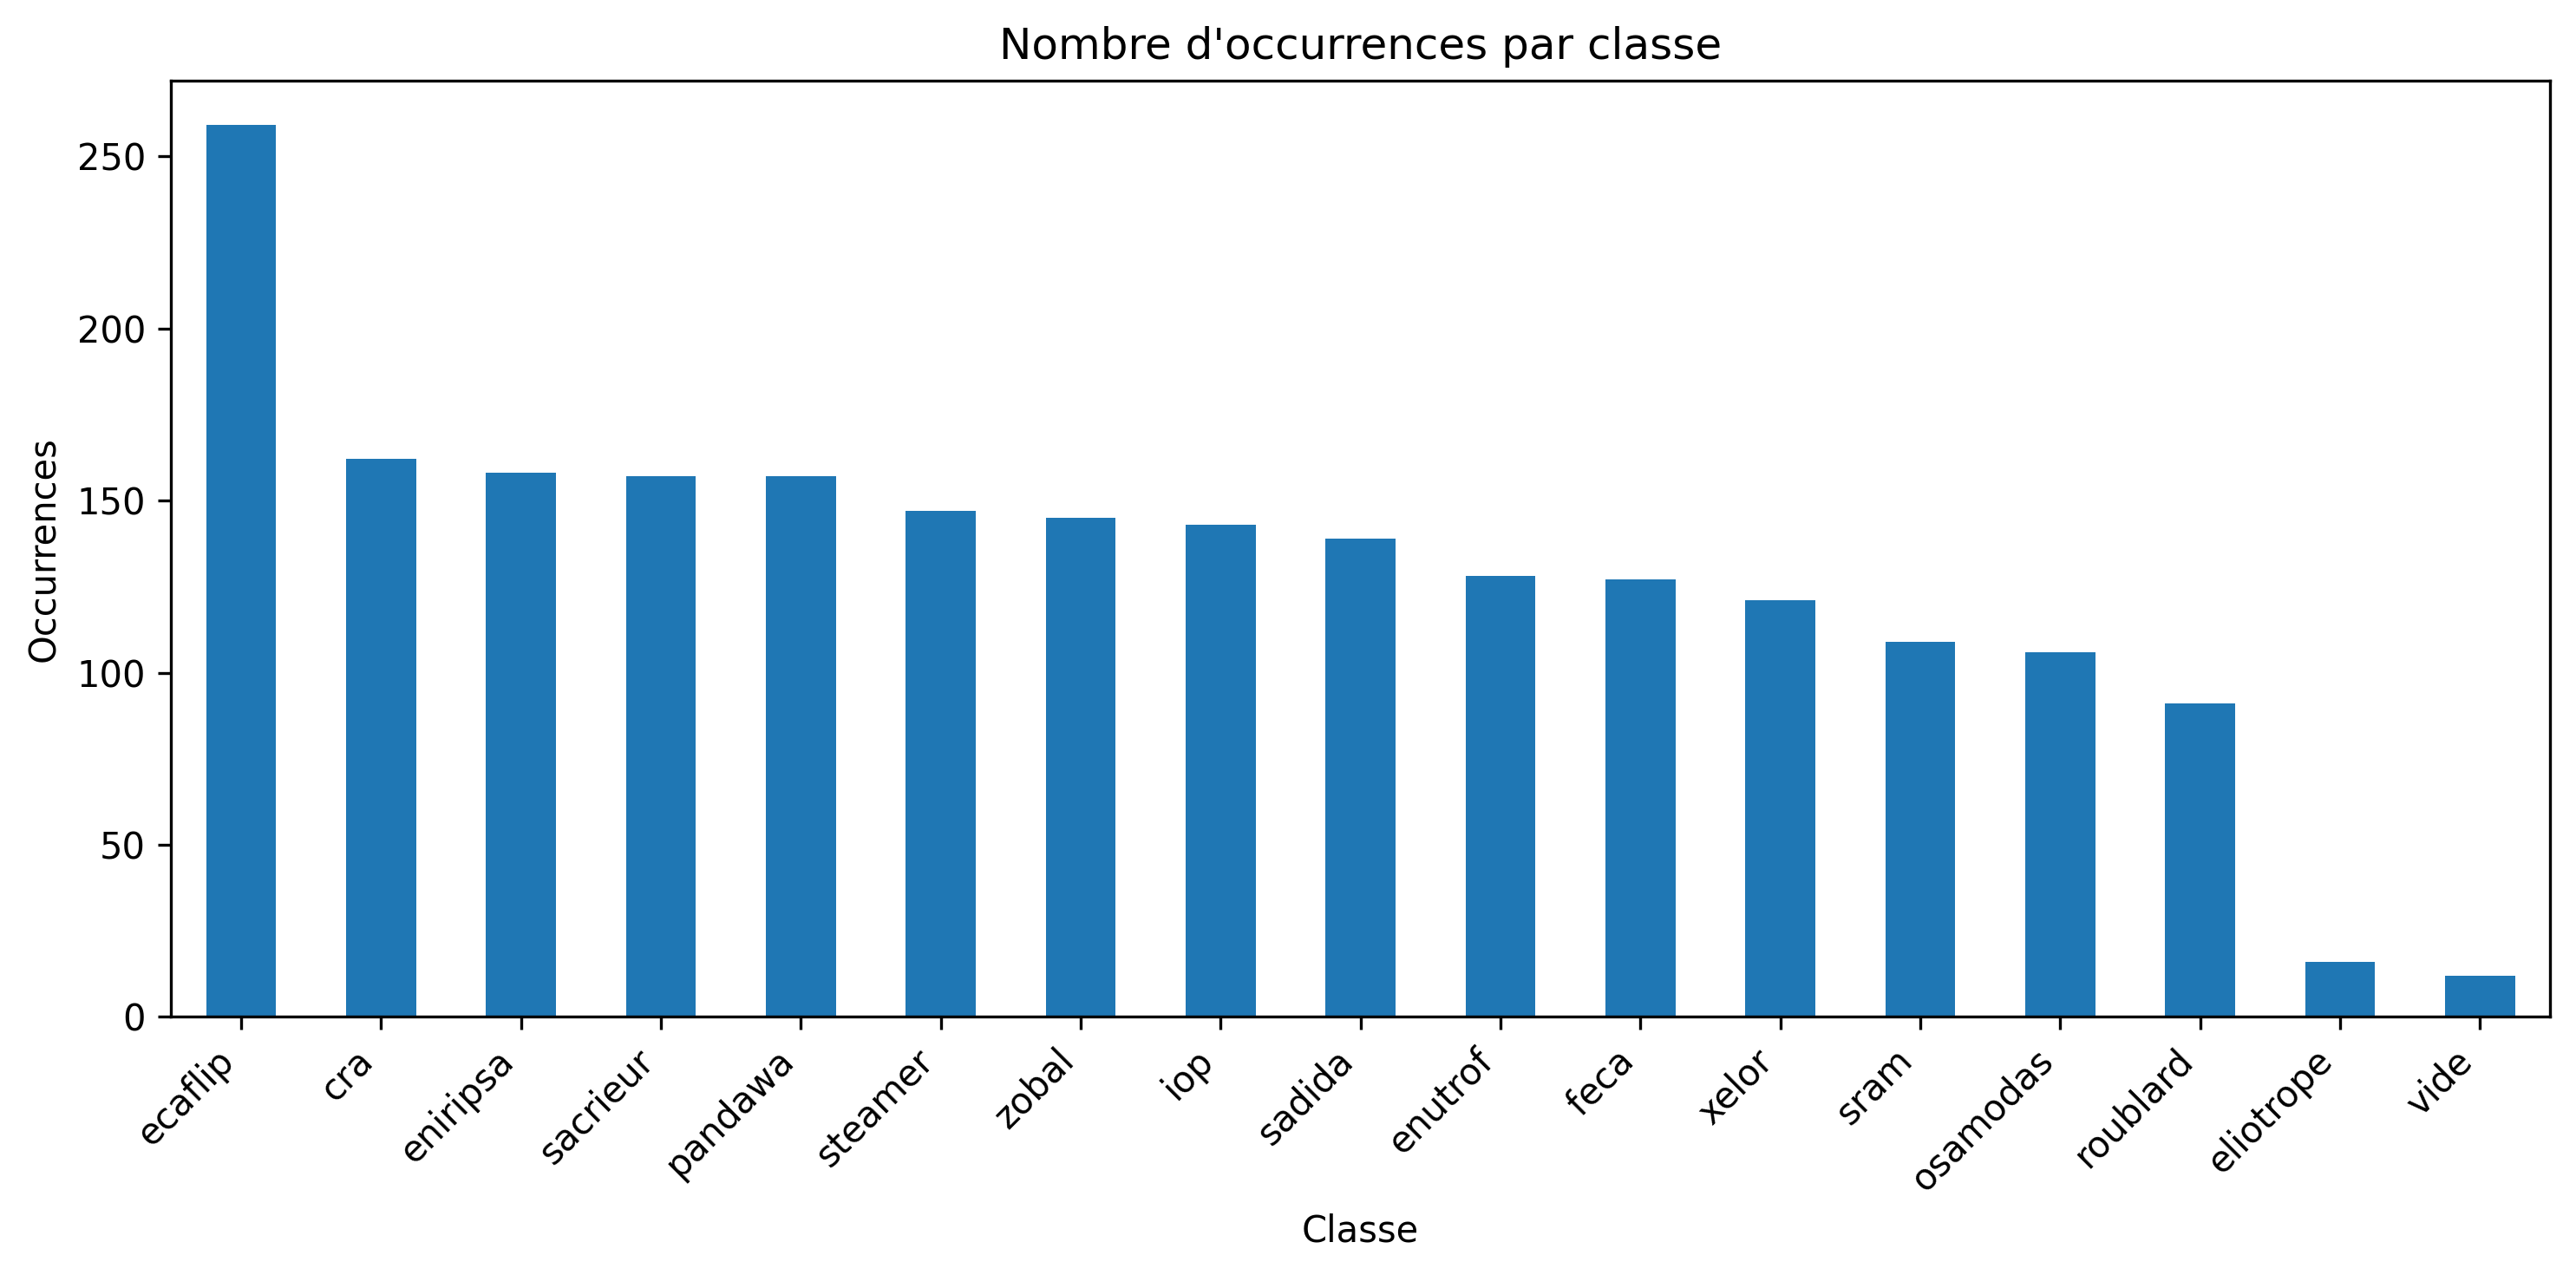

In [19]:
plt.figure(figsize=(10,5), dpi=300)
classe_counts_filtered.plot(kind='bar')
plt.title("Nombre d'occurrences par classe")
plt.xlabel("Classe")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


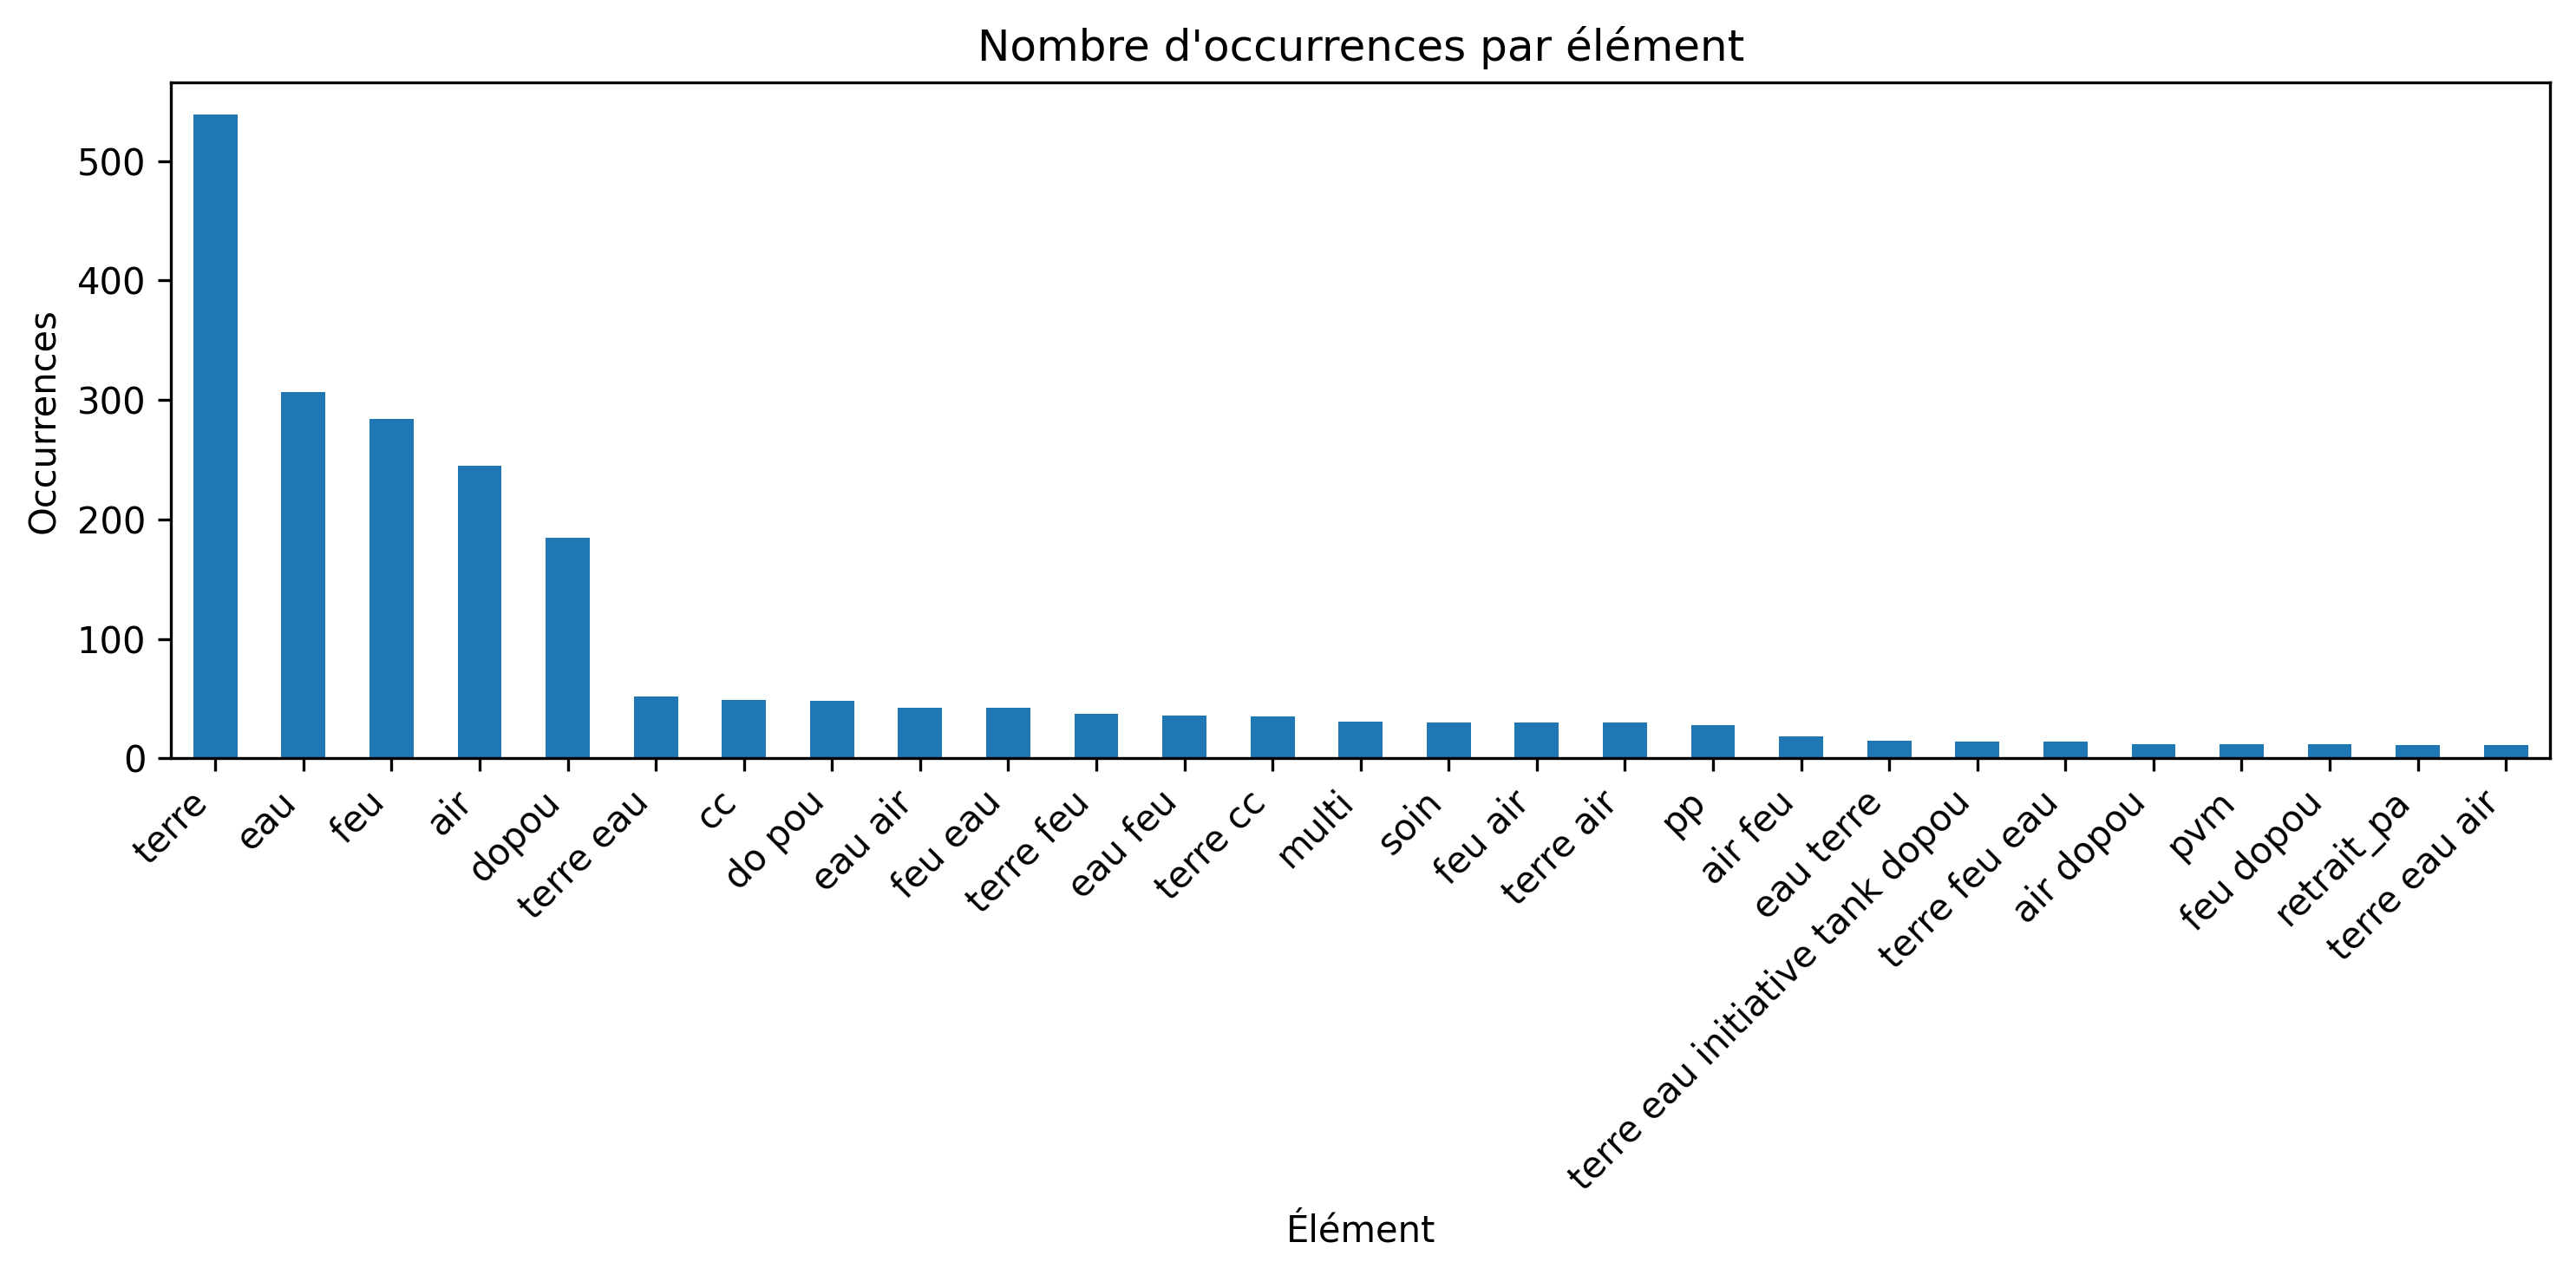

In [20]:
plt.figure(figsize=(10,5), dpi=300)
element_counts_filtered.plot(kind='bar')
plt.title("Nombre d'occurrences par élément")
plt.xlabel("Élément")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#fun car do pou ne marche pas mais y'a énormément de gens qui font l'erreur
